In [1]:
%load_ext autoreload
%autoreload 2
from tqdm.auto import tqdm
import os
os.chdir("/home/xulu/code/alison_spyglass")
from alison_behav import *


import datajoint as dj
from spyglass.utils.dj_helper_fn import fetch_nwb
from spyglass.common import AnalysisNwbfile

behavior_model_table = dj.FreeTable(
    dj.conn(), "`alison_rlmodel`.`__behavior_model_results__by_day`"
)

subject = "wilbur"
date = "20210404"
file_name = subject + date
nwb_file_name = file_name + "_.nwb"
behavior_model_params_name = "default_hmm"
trials_info_by_rat_params_name = "decay_default"  # For some animals or sessions it could be 'decay_default2' where Alison reran the HMM
behav_results = behavior_model_table & {
    "nwb_file_name": nwb_file_name,
    "behavior_model_params_name": behavior_model_params_name,
    "trials_info_by_rat_params_name": trials_info_by_rat_params_name,
}

all_behav = fetch_nwb(behav_results, (AnalysisNwbfile, "analysis_file_abs_path"))[0][
    "behavior_model_results_by_day"
]
all_behav

behav_results
script_table = StateScriptTrials() & {"nwb_file_name": nwb_file_name}
trials = []
epoch = []
t_poke = []
t_out = []
for epoch_i in script_table.fetch("epoch"):
    table = script_table & {"epoch": epoch_i}
    trials.extend(table.fetch1("trial"))
    epoch.extend([epoch_i] * len(table.fetch1("trial")))
    t_poke.extend(table.fetch1("poke_in_ts"))
    t_out.extend(table.fetch1("poke_out_ts"))
script_df = pd.DataFrame(
    {"epoch": epoch, "trial_number_by_epoch": trials, "t_poke": t_poke, "t_out": t_out},
)
script_df

##
trial_df = pd.merge(all_behav, script_df, on=["epoch", "trial_number_by_epoch"])
turn_lookup = {
    (1, 2): "right",
    (2, 1): "left",
    (3, 4): "right",
    (4, 3): "left",
    (5, 6): "right",
    (6, 5): "left",
}

fill_entries = [
    (1, "left", [3, 4, 5, 6]),
    (2, "right", [3, 4, 5, 6]),
    (3, "left", [1, 2, 5, 6]),
    (4, "right", [1, 2, 5, 6]),
    (5, "left", [1, 2, 3, 4]),
    (6, "right", [1, 2, 3, 4]),
]
for fill_entry in fill_entries:
    port, turn, other_ports = fill_entry
    for other_port in other_ports:
        turn_lookup[(port, other_port)] = turn

turns = []
for epoch in trial_df["epoch"].unique():
    epoch_df = trial_df[trial_df["epoch"] == epoch]
    turns.append("start")
    for i in range(1, len(epoch_df)):
        turn = turn_lookup[(epoch_df["leaf"].values[i - 1], epoch_df["leaf"].values[i])]
        turns.append(turn)
if "turns" not in trial_df.columns:
    trial_df["turns"] = turns


prev_trial_reward = []
for epoch in trial_df["epoch"].unique():
    epoch_df = trial_df[trial_df["epoch"] == epoch]
    prev_trial_reward.append(np.nan)
    prev_trial_reward.extend(epoch_df["reward"].values[:-1].tolist())
if "prev_trial_reward" not in trial_df.columns:
    trial_df["prev_trial_reward"] = prev_trial_reward

run_starts = []
for epoch in trial_df["epoch"].unique():
    epoch_df = trial_df[trial_df["epoch"] == epoch]
    run_starts.append(np.nan)
    run_starts.extend(epoch_df["t_out"].values[:-1].tolist())
if "run_start" not in trial_df.columns:
    trial_df["run_start"] = run_starts


from spyglass.common import Nwbfile
from pynwb import NWBHDF5IO
from spyglass.utils.nwb_helper_fn import get_nwb_file
from spyglass.utils.dj_helper_fn import _get_nwb_object
from spyglass.common import DIOEvents, Nwbfile, interval_list_intersect
import numpy as np

file_path = Nwbfile().get_abs_path("wilbur20210404_.nwb")
nwb = get_nwb_file(file_path)
dio_query = (
    DIOEvents()
    & {"nwb_file_name": "wilbur20210404_.nwb"}
    & "dio_event_name LIKE 'pump%'"
)

pump_obj_ids = dio_query.fetch("dio_object_id")
all_pump_intervals = []
for obj_id in pump_obj_ids:
    obj = _get_nwb_object(nwb.objects, obj_id)
    state = obj.data[:]
    state_time = obj.timestamps[:]
    ind_on = np.where(state == 1)[0]
    pump_intervals = [
        [st, en] for st, en in zip(state_time[ind_on], state_time[ind_on + 1])
    ]
    all_pump_intervals.extend(pump_intervals)
all_pump_intervals = np.array(all_pump_intervals)
ind = np.argsort(all_pump_intervals[:, 0])
all_pump_intervals = all_pump_intervals[ind]

dio_query = (
    DIOEvents()
    & {"nwb_file_name": "wilbur20210404_.nwb"}
    & "dio_event_name LIKE 'poke%'"
)
poke_obj_ids = dio_query.fetch("dio_object_id")
all_poke_intervals = []
for obj_id in poke_obj_ids:
    obj = _get_nwb_object(nwb.objects, obj_id)
    state = obj.data[:]
    state_time = obj.timestamps[:]
    ind_on = np.where(state == 1)[0]
    poke_intervals = [
        [st, en] for st, en in zip(state_time[ind_on], state_time[ind_on + 1])
    ]
    all_poke_intervals.extend(poke_intervals)
all_poke_intervals = np.array(all_poke_intervals)
ind = np.argsort(all_poke_intervals[:, 0])
all_poke_intervals = all_poke_intervals[ind]

[2026-05-27 11:19:41,141][INFO]: DataJoint 0.14.9 connected to sambray@lmf-db.cin.ucsf.edu:3306
[11:19:45][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
	Use table.fetch_nwb() method (logic integrated into FetchMixin) instead
[11:19:45][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use FetchMixin.fetch_nwb() (logic integrated into mixin) instead
/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmappe

In [2]:
import datajoint as dj

key = {"nwb_file_name": "Wilbur20210404_.nwb"}
schema = dj.schema("alison_decoding")

schema.list_tables()

table_name = "`alison_decoding`.`__clusterless_acausal_results_summary`"
acausal_results_table = dj.FreeTable(dj.conn(), table_name)

acausal_results_keys = (acausal_results_table & key).fetch("KEY")  # [0]
acausal_results = acausal_results_table & acausal_results_keys
nwb_list = fetch_nwb(acausal_results, (AnalysisNwbfile, "analysis_file_abs_path"))
decoding_df = pd.concat([nwb["results_df"] for nwb in nwb_list], ignore_index=True)
decoding_df.set_index("time", inplace=True)

[11:25:49][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
	Use table.fetch_nwb() method (logic integrated into FetchMixin) instead
[11:25:49][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use FetchMixin.fetch_nwb() (logic integrated into mixin) instead
/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.mode

In [3]:
out_path = "/stelmo/sam/c3po_datasets/wilbur20210404_big_df.pkl"
alison_df = pd.read_pickle(out_path)
INITIAL_Q = 0.5

actual_segment = alison_df.actual_segment.values
seg_switch_points = np.where(actual_segment[:-1] != actual_segment[1:])[0] + 1
# print(len(seg_switch_points))
from_first_seg = alison_df.is_first_seg_of_trial.iloc[seg_switch_points - 1].values
first_choice_point_inds = seg_switch_points[from_first_seg]
first_choice_point_inds
choice_point_times = alison_df.index.values[first_choice_point_inds]
len(choice_point_times)

trial_t_choice = []
for st, en in zip(trial_df["run_start"], trial_df["t_poke"]):
    ind = np.where((choice_point_times >= st) & (choice_point_times <= en))[0]
    if len(ind) == 1:
        trial_t_choice.append(choice_point_times[ind[0]])
    elif len(ind) == 0:
        trial_t_choice.append(np.nan)
    else:
        raise ValueError("Multiple choice points found in a trial!")
len(trial_t_choice)

if "t_choice" not in trial_df.columns:
    trial_df["t_choice"] = trial_t_choice
# alison_df.columns
Q_array = trial_df[[f"Q{i}" for i in range(1, 7)]].values + INITIAL_Q
Q_trial = np.array(
    [Q_array[i, trial_df.leaf.values[i] - 1] for i in range(len(trial_df))]
)
Q_trial.shape
if "Q_trial" not in trial_df.columns:
    trial_df["Q_trial"] = Q_trial
Q_stem_array = trial_df[[f"Qstem{i}" for i in range(1, 4)]].values
stem_dict = {"A": 0, "B": 1, "C": 2}
trial_stem_index = np.array([stem_dict[s] for s in trial_df.stem.values])
Q_stem_trial = np.array(
    [Q_stem_array[i, trial_stem_index[i]] for i in range(len(trial_df))]
)
if not "Q_stem_trial" in trial_df.columns:
    trial_df["Q_stem_trial"] = Q_stem_trial

In [4]:
if not "Q_stem_trial" in trial_df.columns:
    trial_df["Q_stem_trial"] = Q_stem_trial
Q_stem_max = Q_stem_array.max(axis=1)
switch_val = Q_stem_max - Q_stem_trial
if not "switch_val" in trial_df.columns:
    trial_df["switch_val"] = switch_val

Q_next_stem = trial_df.Q_stem_trial.values[1:]
Q_next_stem = trial_df.Q_stem_trial.shift(-1)

Q_next_stem[:9] - trial_df.Q_stem_trial[1:10]
if "Q_next_stem" not in trial_df.columns:
    trial_df["Q_next_stem"] = Q_next_stem


previous_leaf = trial_df.leaf.shift(1)
Q_prev_trial_updated = np.array(
    [Q_array[i, int(previous_leaf.values[i]) - 1] for i in range(1, len(trial_df))]
)
Q_prev_trial = np.array(
    [Q_array[i - 1, int(previous_leaf.values[i]) - 1] for i in range(1, len(trial_df))]
)
Q_prev_trial = np.insert(Q_prev_trial, 0, np.nan)
if "Q_prev_trial" not in trial_df.columns:
    trial_df["Q_prev_trial"] = Q_prev_trial

Q_prev_trial_updated = np.insert(Q_prev_trial_updated, 0, np.nan)
if "Q_prev_trial_updated" not in trial_df.columns:
    trial_df["Q_prev_trial_updated"] = Q_prev_trial_updated

In [5]:
from spyglass.spikesorting.analysis.v1.group import SortedSpikesGroup

key = {"nwb_file_name": "wilbur20210404_.nwb"}
spikes_query = SortedSpikesGroup() & key

spikes_query
spikes_key = spikes_query.fetch1("KEY")
spikes = (spikes_query).fetch_spike_data(spikes_key)

/home/sambray/.local/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an attribute (dtype: text) while the core schema defines it as a link to DeviceModel. 
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a DeviceModel. Remapping "unknown" to a new DeviceModel.
  override = self.__get_override_carg(argname, builder, manager)
/home/sambray/.local/lib/python3.10/site-packages/hdmf/build/objectmapper.py:1399: UserWarning: Device.model was detected as a string, but NWB 2.9 specifies Device.model as a link to a Dev

# Load model

In [6]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt

os.chdir("/home/sambray/Documents/c3po")
from src.c3po.tables.dev_tables import C3POStorage

# model_name = "rat_mpfc_model1_c20z20"
# model_name = "rat_mpfc_model202604_16dim_deep_trained"
# model_name = "rat_mpfc_model202604_20dim_runEpochs"
model_name = "rat_mpfc_model202604_20dim_runEpochs_smooth"
# model_name = "rat_mpfc_model202604_32dim_runEpochs_smooth"

model_key = {"model_name": model_name}
analysis = (C3POStorage & model_key).fetch_analysis_object()

analysis.load_embedding(
    f"/stelmo/sam/c3po_results/{model_key['model_name']}_embedding.npz"
)

t_interp = np.arange(analysis.t[0], analysis.t[-1], 0.001)
analysis.interpolate_context(t_interp)
# analysis.fit_context_pca()

# analysis.embed_context_pca()


# define figure directory
from src.c3po.analysis.analysis import figure_directory
from pathlib import Path

figure_directory = Path(figure_directory)
figure_folder = figure_directory / "Fig5" / model_name
os.makedirs(figure_folder, exist_ok=True)
plt.rcParams["svg.fonttype"] = "none"  # to get editable text in Illustrator

/home/sambray/mambaforge-pypy3/envs/c3po_spyglass/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(


x shape (1, 33)


In [7]:
from spyglass.common import IntervalList

interval_query = (
    IntervalList & {"nwb_file_name": "wilbur20210404_.nwb"} & "pipeline LIKE 'sb%'"
)
rewarded_port_intervals = interval_query.fetch1("valid_times")

In [8]:
from spyglass.common import TaskEpoch

run_query = (TaskEpoch() & {"nwb_file_name": "wilbur20210404_.nwb"}) - {
    "task_name": "sleep"
}
run_epoch_intervals = (IntervalList & run_query).fetch("valid_times")

run_epoch_intervals = np.concatenate(run_epoch_intervals, axis=0)
analysis.fit_context_pca(fit_intervals=run_epoch_intervals)
analysis.embed_context_pca()

# Aligned response

(array([105., 343., 153.,  15., 129., 208., 123., 106., 217., 100.]),
 array([0.12187478, 0.16478095, 0.20768711, 0.25059327, 0.29349944,
        0.3364056 , 0.37931177, 0.42221793, 0.46512409, 0.50803026,
        0.55093642]),
 <BarContainer object of 10 artists>)

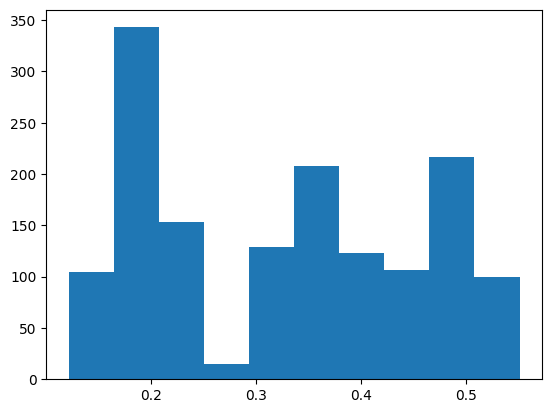

In [71]:
plt.hist(trial_df["Q_prev_trial"])

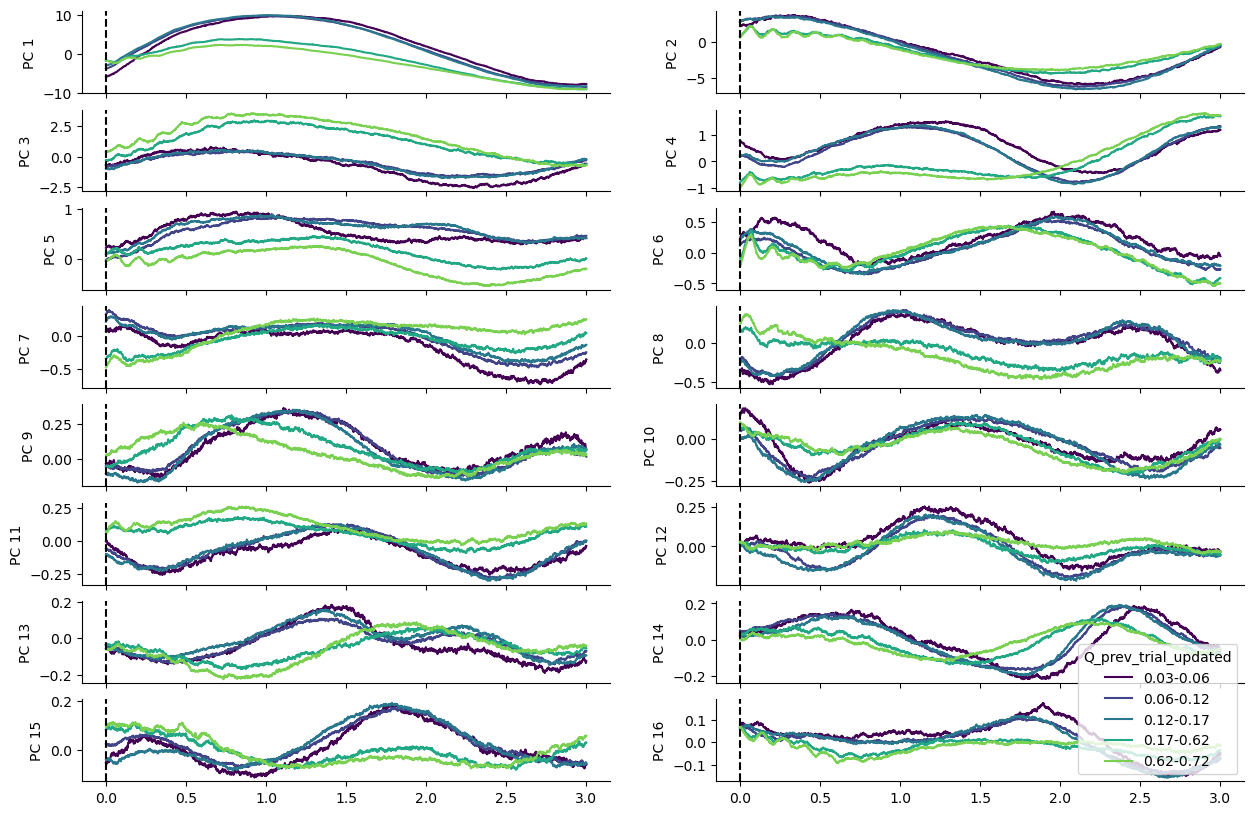

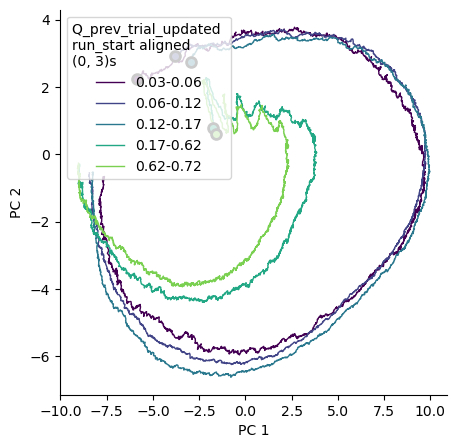

In [10]:
two_dim = [5, 6]
two_dim = [0, 1]
# two_dim = [1, 2]

# -----------------------
mark_feature = "t_out"
window = (-2, 1)

# mark_feature = "t_poke"
# window = (-.5, 1.5)

mark_feature = "run_start"
window = (-0, 3)

# mark_feature = "t_choice"
# window = (-1, 1)

# -----------------------
group_feature = "reward"
feature_bins = None

group_feature = "prev_trial_reward"
feature_bins = None

# group_feature = "stem_stay_p"
# feature_bins = np.linspace(0, 1, 11).round(2)
# feature_bins = np.percentile(
#     trial_df[group_feature].values, np.linspace(10, 90, 6)
# ).round(2)

# group_feature = "stem_choice_p"
# feature_bins = np.linspace(0, 1, 11).round(2)
# exclude_labels = ["start"]

group_feature = "Q_prev_trial_updated"
feature_bins = np.nanpercentile(
    trial_df[group_feature].values, np.linspace(0, 100, 6)
).round(2)

# group_feature = "Q_stem_trial"
# feature_bins = np.linspace(0, 0.8, 8).round(2)
# feature_bins = np.percentile(
#     trial_df["Q_stem_trial"].values, np.linspace(10, 90, 6)
# ).round(2)

# group_feature = "turns"
# feature_bins = None

# group_feature = "n_pre_switch"
# feature_bins = np.arange(5) + 0.1

# ------------------------
exclude_feature = "n_pre_switch"
exclude_feature_values = [0, -1]
exclude_labels = [None]

# exclude_feature = "reward"
# exclude_feature_values = [1]


# ------------------------
if exclude_feature is None:
    exclude_mask = np.zeros(len(trial_df), dtype=bool)
else:
    val = trial_df[exclude_feature].values
    exclude_mask = np.isin(val, exclude_feature_values)

if feature_bins is None:
    feature_values = trial_df[group_feature].values
    feature_labels = np.unique(feature_values).tolist()
    feature_labels = [
        label
        for label in feature_labels
        if (isinstance(label, str)) or not np.isnan(label)
    ]
    feature_labels = [label for label in feature_labels if label not in exclude_labels]
    category_inds = [feature_values == val for val in feature_labels]

else:
    feature_values = trial_df[group_feature].values
    category_inds = []
    feature_labels = []
    for lo, hi in zip(feature_bins[:-1], feature_bins[1:]):
        inds = (feature_values >= lo) & (feature_values <= hi)
        category_inds.append(inds)
        feature_labels.append(f"{lo}-{hi}")
# ---


fig, ax = plt.subplots(
    min(8, analysis.context_dim // 2), ncols=2, figsize=(15, 10), sharex=True
)
ax = ax.flatten()

fig_2d, ax_2d = plt.subplots(figsize=(5, 5))
for i_cat, (inds, label) in enumerate(zip(category_inds, feature_labels)):
    if inds.sum() == 0:
        continue
    marks = trial_df[mark_feature].values[np.logical_and(inds, ~exclude_mask)]

    response = analysis.alligned_response(marks, window, pca=True)
    mean_response = np.nanmean(response, axis=0)
    color = plt.cm.viridis(i_cat / len(category_inds))
    t_plot = np.linspace(
        window[0],
        window[1],
        mean_response.shape[0],
    )
    for i_dim, a in enumerate(ax):
        a.plot(t_plot, mean_response[:, i_dim], label=label, color=color)
        a.set_ylabel(f"PC {i_dim+1}")

    ax_2d.plot(
        mean_response[:, two_dim[0]],
        mean_response[:, two_dim[1]],
        label=label,
        color=color,
        lw=1,
        zorder=-1,
    )
    ax_2d.scatter(
        mean_response[0, two_dim[0]],
        mean_response[0, two_dim[1]],
        color=color,
        s=50,
        edgecolors="k",
        lw=2,
    )

for a in ax:
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.axvline(0, color="k", linestyle="--")
ax[-1].legend(title=f"{group_feature}")

ax_2d.spines[["top", "right"]].set_visible(False)
ax_2d.set_xlabel(f"PC {two_dim[0]+1}")
ax_2d.set_ylabel(f"PC {two_dim[1]+1}")
ax_2d.legend(
    title=f"{group_feature} \n{mark_feature} aligned \n({window[0]}, {window[1]})s"
)

In [74]:
feature_bins

array([nan, nan, nan])

# decode progression

In [17]:
from spyglass.common.common_interval import Interval

# first_run_epoch = Interval([run_epoch_intervals[0]])

# t_mark = trial_df.run_start.values
# t_mark = t_mark[~np.isnan(t_mark)]
# t_mark = first_run_epoch.contains(t_mark)[:30]

# feature_array = np.arange(0, 2, 0.001)

# t_feature = [feature_array + t for t in t_mark]
# feature = [feature_array for _ in t_mark]
# t_feature = np.ravel(t_feature)
# feature = np.ravel(feature)

# feature_intervals = [[t, t + 2] for t in t_mark]


t_run_norm = np.ones_like(analysis.t_interp) * -1
for st, en in trial_df[["run_start", "t_poke"]].values:
    if np.isnan(st) or np.isnan(en):
        continue
    ind_st = np.searchsorted(analysis.t_interp, st)
    ind_en = np.searchsorted(analysis.t_interp, en)
    t_run_norm[ind_st:ind_en] = np.linspace(0, 1, ind_en - ind_st)
_df = trial_df[trial_df.n_pre_switch != 0]
feature_intervals = _df[["run_start", "t_poke"]].values
feature = t_run_norm
t_feature = analysis.t_interp

In [40]:
feature_bins = np.linspace(0, 1, 31)
skip_inds = []

df_ref = trial_df.copy()
df_ref = df_ref[df_ref.n_pre_switch != 0]
df_ref = df_ref[df_ref.n_post_switch > 1]


df_1 = df_ref.copy()
df_1 = df_1[df_1.prev_trial_reward == 0]
df_2 = df_ref.copy()
df_2 = df_2[df_2.prev_trial_reward == 1]
test_list = [df_1, df_2]
name_list = ["prev_reward_0", "prev_reward_1"]


# group_feature = "Q_prev_trial"
# lo = np.nanpercentile(df_ref[group_feature].values, 10)
# hi = np.nanpercentile(df_ref[group_feature].values, 90)
# df_1  = df_ref.copy()
# df_1 = df_1[df_1[group_feature] <= lo]
# df_2 = df_ref.copy()
# df_2 = df_2[df_2[group_feature] >= hi]
# test_list = [df_1, df_2]
# name_list = ["low_"+group_feature, "high_"+group_feature]

# df_1 = df_ref.copy()
# df_1 = df_1[df_1.n_pre_switch <= 1]
# df_2 = df_ref.copy()
# df_2 = df_2[df_2.n_pre_switch >= 4]
# test_list = [df_1, df_2]
# name_list = ["n_pre_switch_low", "n_pre_switch_high"]

# group_feature = "Q_prev_trial_updated"
# lo_thresh = np.nanpercentile(df_ref[group_feature].values, 20)
# hi_thresh = np.nanpercentile(df_ref[group_feature].values, 80)
# df_1 = df_ref.copy()
# df_1 = df_1[df_1[group_feature] <= lo_thresh]
# df_2 = df_ref.copy()
# df_2 = df_2[df_2[group_feature] >= hi_thresh]
# test_list = [df_1, df_2]
# name_list = [f"{group_feature}_low", f"{group_feature}_high"]

results = np.zeros((len(spikes), len(feature_bins) - 1))
norm = np.zeros(len(feature_bins) - 1)
_df = df_ref
for time_st, time_en in tqdm(
    zip(_df.run_start.values, _df.t_poke.values), total=len(_df)
):
    st_feature = np.searchsorted(t_feature, time_st)
    en_feature = np.searchsorted(t_feature, time_en)
    clip_feature = feature[st_feature:en_feature]
    clip_t_feature = t_feature[st_feature:en_feature]
    norm = norm + np.histogram(clip_feature, bins=feature_bins)[0]
    for i, s in enumerate(spikes):
        st = np.searchsorted(s, time_st)
        en = np.searchsorted(s, time_en)
        if en - st < 1:
            continue
        ind_spike = np.digitize(s[st:en], clip_t_feature, right=False) - 1
        results[i, :] = (
            results[i, :] + np.histogram(clip_feature[ind_spike], bins=feature_bins)[0]
        )
ref_results = results / norm

test_results = []
for _df in test_list:
    norm = np.zeros(len(feature_bins) - 1)
    results = np.zeros((len(spikes), len(feature_bins) - 1))
    for time_st, time_en in tqdm(
        zip(_df.run_start.values, _df.t_poke.values), total=len(_df)
    ):
        st_feature = np.searchsorted(t_feature, time_st)
        en_feature = np.searchsorted(t_feature, time_en)
        clip_feature = feature[st_feature:en_feature]
        clip_t_feature = t_feature[st_feature:en_feature]
        norm = norm + np.histogram(clip_feature, bins=feature_bins)[0]
        for i, s in enumerate(spikes):
            st = np.searchsorted(s, time_st)
            en = np.searchsorted(s, time_en)
            if en - st < 1:
                continue
            ind_spike = np.digitize(s[st:en], clip_t_feature, right=False) - 1
            results[i, :] = (
                results[i, :]
                + np.histogram(clip_feature[ind_spike], bins=feature_bins)[0]
            )
    test_results.append(results / norm)

  0%|          | 0/1083 [00:00<?, ?it/s]

  0%|          | 0/686 [00:00<?, ?it/s]

  0%|          | 0/397 [00:00<?, ?it/s]

/tmp/ipykernel_3681391/630227384.py:16: RuntimeWarning: invalid value encountered in divide
  yy = yy / np.mean(yy, axis=1, keepdims=True)
/tmp/ipykernel_3681391/630227384.py:18: RuntimeWarning: divide by zero encountered in log2
  yy = np.log2(yy)


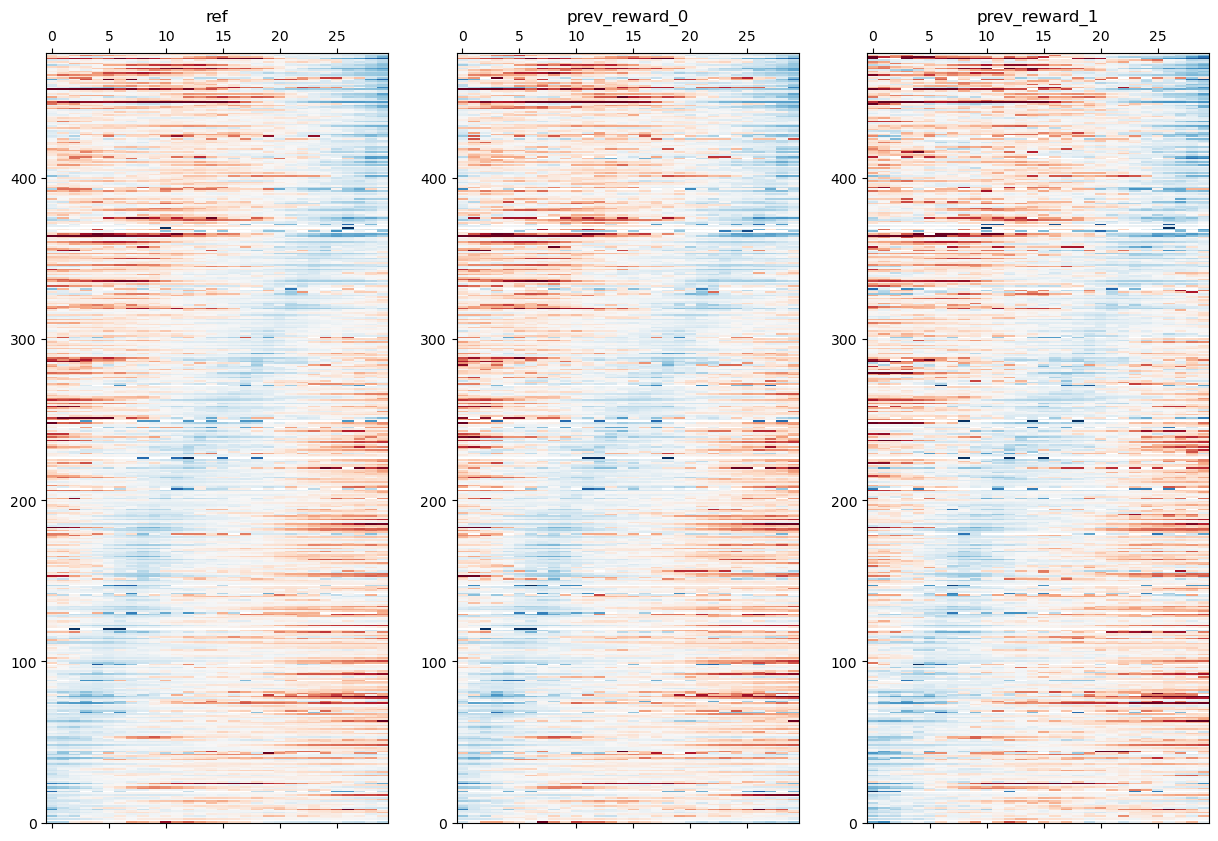

In [ ]:
ind_sort = np.argsort(np.argmax(ref_results, axis=1))
# ind_sort = np.argsort(np.argmax(test_results[0], axis=1))
common_ref = 0

fig, ax = plt.subplots(
    ncols=1 + len(test_results), figsize=(5 * (1 + len(test_results)), 10)
)

names = ["ref"] + name_list
data_list = [ref_results] + test_results
for i, (results, name) in enumerate(zip([ref_results] + test_results, names)):
    yy = results[ind_sort]
    if common_ref:
        yy = yy / np.mean(ref_results[ind_sort], axis=1, keepdims=True)
    else:
        yy = yy / np.mean(yy, axis=1, keepdims=True)

    yy = np.log2(yy)
    ax[i].matshow(yy, aspect="auto", origin="lower", cmap="RdBu", clim=(-3, 3))

    # ax[i].matshow(yy, aspect="auto", origin="lower", cmap="bone_r",clim = (0,4))
    ax[i].set_title(name)
    # plt.colorbar()

/tmp/ipykernel_2150868/742331525.py:1: RuntimeWarning: divide by zero encountered in divide
  yy = test_results[1][ind_sort] / test_results[0][ind_sort]
/tmp/ipykernel_2150868/742331525.py:1: RuntimeWarning: invalid value encountered in divide
  yy = test_results[1][ind_sort] / test_results[0][ind_sort]
/tmp/ipykernel_2150868/742331525.py:3: RuntimeWarning: divide by zero encountered in log2
  yy = np.log2(yy)


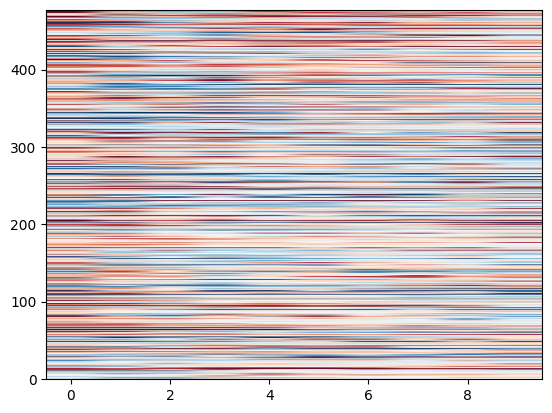

In [ ]:
yy = test_results[1][ind_sort] / test_results[0][ind_sort]

yy = np.log2(yy)

plt.imshow(yy, aspect="auto", origin="lower", cmap="RdBu", clim=(-1, 1))

# Old

# Spike Responses

## Runs

In [ ]:
_df = trial_df
_df = _df[trial_df.reward == 1]
_df = _df[_df.n_pre_switch > 0]
# _df = _df[_df.prev_trial_reward == 1]

marks = _df.run_start
marks = marks[~np.isnan(marks)]
marks = marks[:]

run_durations = _df.t_poke.values - _df.run_start.values
run_durations = run_durations[~np.isnan(run_durations)]

choice_durations = _df.t_choice.values - _df.run_start.values
choice_durations = choice_durations[~np.isnan(choice_durations)]

out_durations = _df.t_out.values - _df.run_start.values
out_durations = out_durations[~np.isnan(out_durations)]

t_bins_run = np.arange(-2, 12, 0.1)
# t_bins_run = np.arange(-4, 12, 0.01)
# t_bins_run = np.arange(-4, 4, 0.1)
results = np.zeros((len(spikes), len(t_bins_run) - 1))

for m in tqdm(marks):
    # rates = SortedSpikesGroup.get_firing_rate(spikes_key, t_bins + m, smoothing_sigma=.01)
    # results.append(rates)
    for i, s in enumerate(spikes):
        st = np.searchsorted(s, m + t_bins_run[0])
        en = np.searchsorted(s, m + t_bins_run[-1])
        if en <= st:
            continue
        delays = s[st:en] - m
        results[i, :] += np.histogram(delays, bins=t_bins_run)[0]
results_run = np.array(results)
ind_run_sort = np.argsort(np.argmax(results_run, axis=1))
sort_on = np.logical_and(t_bins_run[:-1] < 3, t_bins_run[:-1] > 0)

ind_run_restrictive = np.argsort(np.argmax(results_run[:, sort_on], axis=1))

# context
run_c_response = analysis.alligned_response(
    marks,
    t_plot=(t_bins_run[0], t_bins_run[-1]),
    pca=True,
)
run_c_response = run_c_response.mean(axis=0)

# theta
run_theta_response = analysis.alligned_response(
    marks,
    t_plot=(t_bins_run[0], t_bins_run[-1]),
    passed_data=(power_df.values, power_df.index),
)
run_theta_response = run_theta_response.mean(axis=0)

100%|██████████| 400/400 [00:04<00:00, 86.39it/s]


/tmp/ipykernel_2134881/1421435718.py:12: RuntimeWarning: divide by zero encountered in log2
  yy = np.log2(yy)


Text(0, 0.5, 'Neuron ID')

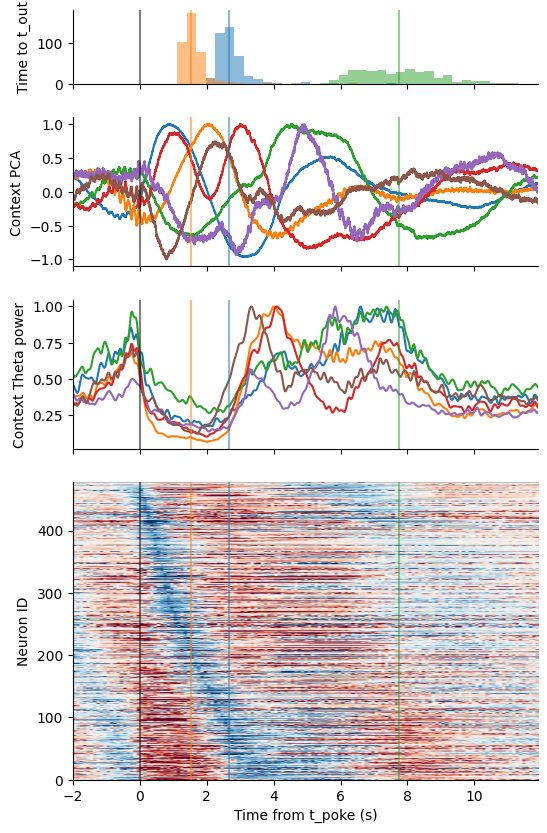

In [ ]:
ind_sort = ind_reward
# ind_sort = ind_no_reward
# ind_sort = ind_run_sort
ind_sort = ind_run_restrictive


fig, ax = plt.subplots(
    nrows=4, height_ratios=[1, 2, 2, 4], sharex=True, figsize=(6, 10)
)
yy = results_run.copy()[ind_sort]
yy = yy / np.mean(yy, axis=1, keepdims=True)
yy = np.log2(yy)

dur_bins = np.linspace(t_bins_run[0], t_bins_run[-1], 50)

alpha = 0.5
ax[0].hist(
    run_durations[~np.isnan(run_durations)], bins=dur_bins, alpha=alpha, label="t_poke"
)
ax[0].hist(
    choice_durations[~np.isnan(choice_durations)],
    bins=dur_bins,
    alpha=alpha,
    label="t_choice",
)
ax[0].hist(
    out_durations[~np.isnan(out_durations)], bins=dur_bins, alpha=alpha, label="t_out"
)

ax[-1].imshow(
    yy,
    aspect="auto",
    extent=[t_bins_run[0], t_bins_run[-1], 0, len(yy)],
    cmap="RdBu",
    clim=(-1, 1),
)
# plt.colorbar()


# context
t_response = np.linspace(t_bins_run[0], t_bins_run[-1], run_c_response.shape[0])
for i in range(6):
    color = plt.cm.Dark2(i)
    color = f"C{i}"
    val = run_c_response[:, i]
    val = (val - np.mean(val)) / np.max(np.abs(val - np.mean(val)))
    ax[1].plot(t_response, val, color=color)

    val = run_theta_response[:, i]
    # val = (val - np.mean(val)) / np.max(np.abs(val - np.mean(val)))
    val = val / np.max(val)
    ax[2].plot(t_response, val, color=color)

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
    ls = "-"
    a.axvline(0, color="k", linestyle=ls, alpha=0.5)
    a.axvline(np.median(run_durations), color=f"C0", linestyle=ls, alpha=0.5)
    a.axvline(np.median(choice_durations), color=f"C1", linestyle=ls, alpha=0.5)
    a.axvline(np.median(out_durations), color=f"C2", linestyle=ls, alpha=0.5)

ax[-1].set_xlabel("Time from t_poke (s)")

ax[0].set_ylabel("Time to t_out")
ax[1].set_ylabel("Context PCA")
ax[2].set_ylabel("Context Theta power")
ax[3].set_ylabel("Neuron ID")

# ax[0].set_title("Reward Stay Runs")
# ax[0].set_title("No Reward Stay Runs")
# ax[0].set_title("All Switch Runs")
# ax[0].set_title("Previous Trial Rewarded Runs")
# ax[0].set_title("Previous Trial No Reward Runs")

In [134]:
np.median(choice_durations)

1.6552743911743164

## t choice

In [278]:
_df = trial_df
# _df = _df[trial_df.reward == 1]
_df = _df[_df.n_pre_switch > 0]
_df = _df[_df.prev_trial_reward == 0]

marks = _df.t_choice
marks = marks[~np.isnan(marks)]
marks = marks[:]

run_durations = _df.t_poke.values - _df.t_choice.values
run_durations = run_durations[~np.isnan(run_durations)]

choice_durations = (_df.t_choice.values - _df.run_start.values) * -1
choice_durations = choice_durations[~np.isnan(choice_durations)]

# out_durations = _df.t_out.values - _df.run_start.values
# out_durations = out_durations[~np.isnan(out_durations)]

t_bins_choice = np.arange(-4, 4, 0.1)
# t_bins_run = np.arange(-4, 12, 0.01)
# t_bins_run = np.arange(-4, 4, 0.1)
results = np.zeros((len(spikes), len(t_bins_choice) - 1))

for m in tqdm(marks):
    # rates = SortedSpikesGroup.get_firing_rate(spikes_key, t_bins + m, smoothing_sigma=.01)
    # results.append(rates)
    for i, s in enumerate(spikes):
        st = np.searchsorted(s, m + t_bins_choice[0])
        en = np.searchsorted(s, m + t_bins_choice[-1])
        if en <= st:
            continue
        delays = s[st:en] - m
        results[i, :] += np.histogram(delays, bins=t_bins_choice)[0]
results_choice = np.array(results)
# ind_run_sort = np.argsort(np.argmax(results_choice, axis=1))
sort_on = np.logical_and(t_bins_choice[:-1] < 2, t_bins_choice[:-1] > -1)

ind_choice = np.argsort(np.argmax(results_choice[:, sort_on], axis=1))

# context
choice_c_response = analysis.alligned_response(
    marks,
    t_plot=(t_bins_choice[0], t_bins_choice[-1]),
    pca=True,
)
choice_c_response = choice_c_response.mean(axis=0)

# theta
choice_theta_response = analysis.alligned_response(
    marks,
    t_plot=(t_bins_choice[0], t_bins_choice[-1]),
    passed_data=(power_df.values, power_df.index),
)
choice_theta_response = choice_theta_response.mean(axis=0)

100%|██████████| 779/779 [00:09<00:00, 79.69it/s]


/tmp/ipykernel_2134881/503738640.py:11: RuntimeWarning: invalid value encountered in divide
  yy = yy / np.mean(yy, axis=1, keepdims=True)
/tmp/ipykernel_2134881/503738640.py:12: RuntimeWarning: divide by zero encountered in log2
  yy = np.log2(yy)


Text(0, 0.5, 'Neuron ID')

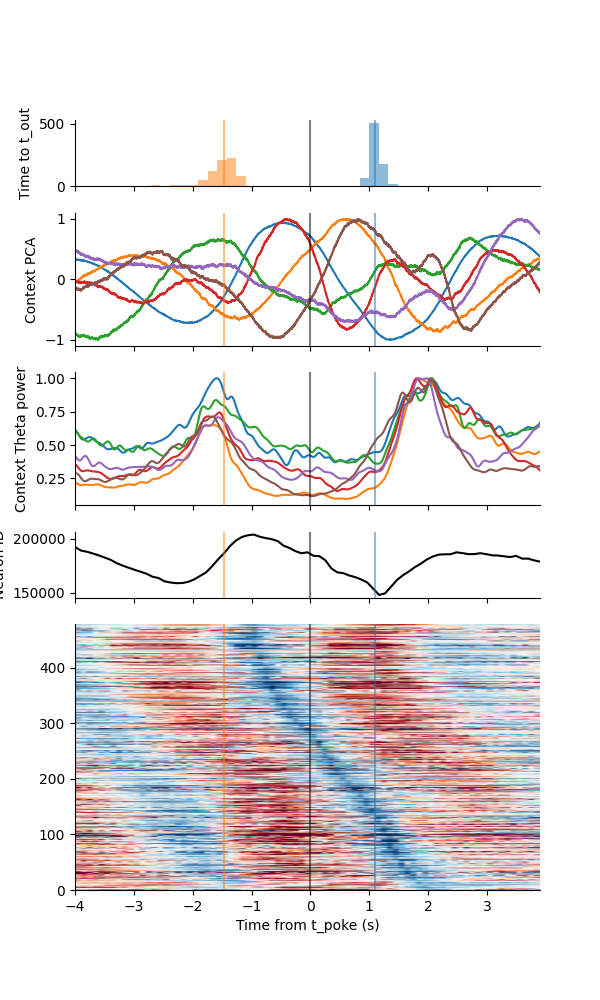

In [294]:
# ind_sort = ind_reward
# ind_sort = ind_no_reward
# ind_sort = ind_run_sort
ind_sort = ind_choice


fig, ax = plt.subplots(
    nrows=5, height_ratios=[1, 2, 2, 1, 4], sharex=True, figsize=(6, 10)
)
yy = results_choice.copy()[ind_sort]
yy = yy / np.mean(yy, axis=1, keepdims=True)
yy = np.log2(yy)

dur_bins = np.linspace(t_bins_choice[0], t_bins_choice[-1], 50)

alpha = 0.5
ax[0].hist(
    run_durations[~np.isnan(run_durations)], bins=dur_bins, alpha=alpha, label="t_poke"
)
ax[0].hist(
    choice_durations[~np.isnan(choice_durations)],
    bins=dur_bins,
    alpha=alpha,
    label="t_choice",
)
# ax[0].hist(
#     out_durations[~np.isnan(out_durations)], bins=dur_bins, alpha=alpha, label="t_out"
# )

ax[-1].imshow(
    yy,
    aspect="auto",
    extent=[t_bins_choice[0], t_bins_choice[-1], 0, len(yy)],
    cmap="RdBu",
    clim=(-1, 1),
)
# plt.colorbar()


# context
t_response = np.linspace(
    t_bins_choice[0], t_bins_choice[-1], choice_c_response.shape[0]
)
for i in range(6):
    color = plt.cm.Dark2(i)
    color = f"C{i}"
    val = choice_c_response[:, i]
    val = (val - np.mean(val)) / np.max(np.abs(val - np.mean(val)))
    ax[1].plot(t_response, val, color=color)

    val = choice_theta_response[:, i]
    # val = (val - np.mean(val)) / np.max(np.abs(val - np.mean(val)))
    val = val / np.max(val)
    ax[2].plot(t_response, val, color=color)

# mua
t_mua = np.linspace(t_bins_choice[0], t_bins_choice[-1], results_choice.shape[1])
ax[3].plot(t_mua, results_choice.sum(axis=0), color="k")

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
    ls = "-"
    a.axvline(0, color="k", linestyle=ls, alpha=0.5)
    a.axvline(np.median(run_durations), color=f"C0", linestyle=ls, alpha=0.5)
    a.axvline(np.median(choice_durations), color=f"C1", linestyle=ls, alpha=0.5)
    # a.axvline(np.median(out_durations), color=f"C2", linestyle=ls, alpha=0.5)

ax[-1].set_xlabel("Time from t_poke (s)")

ax[0].set_ylabel("Time to t_out")
ax[1].set_ylabel("Context PCA")
ax[2].set_ylabel("Context Theta power")
ax[3].set_ylabel("Neuron ID")

# ax[0].set_title("Reward Stay Runs")
# ax[0].set_title("No Reward Stay Runs")
# ax[0].set_title("All Switch Runs")
# ax[0].set_title("Previous Trial Rewarded Runs")
# ax[0].set_title("Previous Trial No Reward Runs")

## Rewarded Poke-in

In [299]:
_df = trial_df[trial_df.reward == 1]
marks = _df.t_poke
marks = marks[~np.isnan(marks)]
marks = marks[:]
reward_durations = _df.t_out.values - _df.t_poke.values

t_bins_reward = np.arange(0, 6, 0.02)
results = np.zeros((len(spikes), len(t_bins_reward) - 1))

for m in tqdm(marks):
    # rates = SortedSpikesGroup.get_firing_rate(spikes_key, t_bins_reward + m, smoothing_sigma=.01)
    # results.append(rates)
    for i, s in enumerate(spikes):
        st = np.searchsorted(s, m + t_bins_reward[0])
        en = np.searchsorted(s, m + t_bins_reward[-1])
        if en <= st:
            continue
        delays = s[st:en] - m
        results[i, :] += np.histogram(delays, bins=t_bins_reward)[0]
results_reward = np.array(results)
sort_on = t_bins_reward[:-1] < 3
ind_reward = np.argsort(np.argmax(results_reward[:, sort_on], axis=1))

# # context
reward_c_response = analysis.alligned_response(
    marks, t_plot=(t_bins_reward[0], t_bins_reward[-1]), pca=True
)
reward_c_response = reward_c_response.mean(axis=0)

reward_theta_response = analysis.alligned_response(
    marks,
    t_plot=(t_bins_reward[0], t_bins_reward[-1]),
    passed_data=(power_df.values, power_df.index),
)
reward_theta_response = reward_theta_response.mean(axis=0)

100%|██████████| 509/509 [00:06<00:00, 80.93it/s]


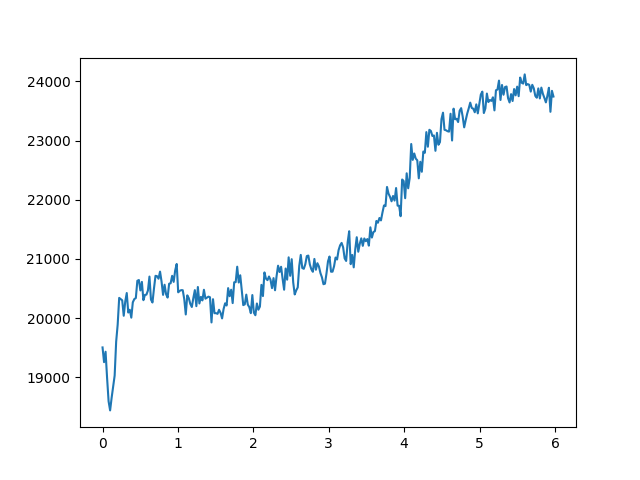

In [300]:
fig = plt.figure()
t_mua = np.linspace(t_bins_reward[0], t_bins_reward[-1], results_reward.shape[1])
plt.plot(t_mua, results_reward.sum(axis=0))

/tmp/ipykernel_2134881/2331774776.py:9: RuntimeWarning: divide by zero encountered in log2
  yy = np.log2(yy)


Text(0.5, 1.0, 'Rewarded trials')

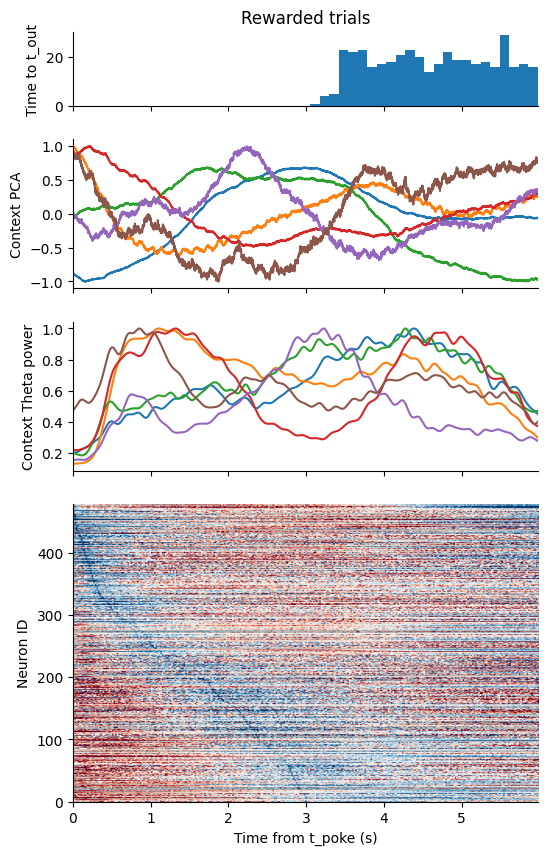

In [ ]:
ind_sort = ind_reward
# ind_sort = ind_no_reward
# ind_sort = ind_run_sort


fig, ax = plt.subplots(
    nrows=4, height_ratios=[1, 2, 2, 4], sharex=True, figsize=(6, 10)
)
yy = results_reward.copy()[ind_sort]
yy = yy / np.mean(yy, axis=1, keepdims=True)
yy = np.log2(yy)

dur_bins = np.linspace(t_bins_reward[0], t_bins_reward[-1], 50)
ax[0].hist(reward_durations[~np.isnan(reward_durations)], bins=dur_bins)
ax[-1].imshow(
    yy,
    aspect="auto",
    extent=[t_bins_reward[0], t_bins_reward[-1], 0, len(yy)],
    cmap="RdBu",
    clim=(-1, 1),
)
# plt.colorbar()


# context
t_response = np.linspace(
    t_bins_reward[0], t_bins_reward[-1], reward_c_response.shape[0]
)
for i in range(6):
    color = plt.cm.Dark2(i)
    color = f"C{i}"
    val = reward_c_response[:, i]
    val = (val - np.mean(val)) / np.max(np.abs(val - np.mean(val)))
    ax[1].plot(t_response, val, color=color)

    val = reward_theta_response[:, i]
    # val = (val - np.mean(val)) / np.max(np.abs(val - np.mean(val)))
    val = val / np.max(val)
    ax[2].plot(t_response, val, color=color)

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
ax[-1].set_xlabel("Time from t_poke (s)")

ax[0].set_ylabel("Time to t_out")
ax[1].set_ylabel("Context PCA")
ax[2].set_ylabel("Context Theta power")
ax[3].set_ylabel("Neuron ID")

ax[0].set_title("Rewarded trials")

## Rewarded Poke Out


In [123]:
_df = trial_df[trial_df.reward == 1]
marks = _df.t_out
marks = marks[~np.isnan(marks)]
marks = marks[:]
reward_durations = _df.t_poke.values - _df.t_out.values

t_bins_reward_out = np.arange(-6, 1, 0.02)
results = np.zeros((len(spikes), len(t_bins_reward_out) - 1))

for m in tqdm(marks):
    # rates = SortedSpikesGroup.get_firing_rate(spikes_key, t_bins_reward + m, smoothing_sigma=.01)
    # results.append(rates)
    for i, s in enumerate(spikes):
        st = np.searchsorted(s, m + t_bins_reward_out[0])
        en = np.searchsorted(s, m + t_bins_reward_out[-1])
        if en <= st:
            continue
        delays = s[st:en] - m
        results[i, :] += np.histogram(delays, bins=t_bins_reward_out)[0]
results_reward_out = np.array(results)
sort_on = np.logical_and(t_bins_reward_out[:-1] < 0, t_bins_reward_out[:-1] > -3)
ind_reward_out = np.argsort(np.argmax(results_reward_out[:, sort_on], axis=1))

# # context
reward_out_c_response = analysis.alligned_response(
    marks, t_plot=(t_bins_reward_out[0], t_bins_reward_out[-1]), pca=True
)
reward_out_c_response = reward_out_c_response.mean(axis=0)

reward_out_theta_response = analysis.alligned_response(
    marks,
    t_plot=(t_bins_reward_out[0], t_bins_reward_out[-1]),
    passed_data=(power_df.values, power_df.index),
)
reward_out_theta_response = reward_out_theta_response.mean(axis=0)

  0%|          | 0/509 [00:00<?, ?it/s]

100%|██████████| 509/509 [00:06<00:00, 76.23it/s]


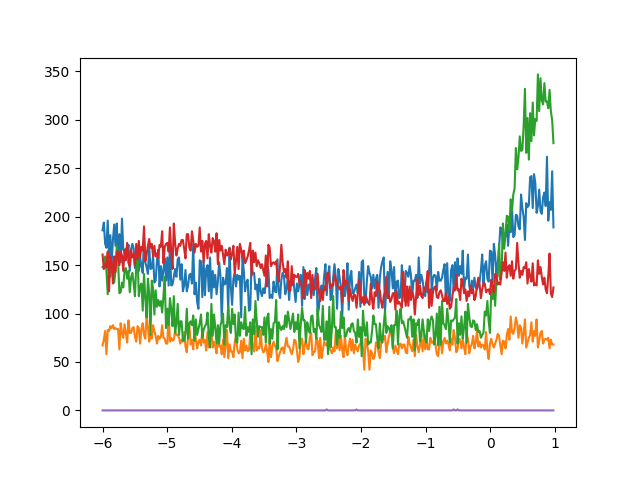

In [ ]:
fig = plt.figure()
t_mua = np.linspace(
    t_bins_reward_out[0], t_bins_reward_out[-1], results_reward_out.shape[1]
)
plt.plot(t_mua, results_reward_out[:5, :].T)

/tmp/ipykernel_2134881/4086149132.py:11: RuntimeWarning: divide by zero encountered in log2
  yy = np.log2(yy)


Text(0.5, 1.0, 'Rewarded trials, Aligned Out')

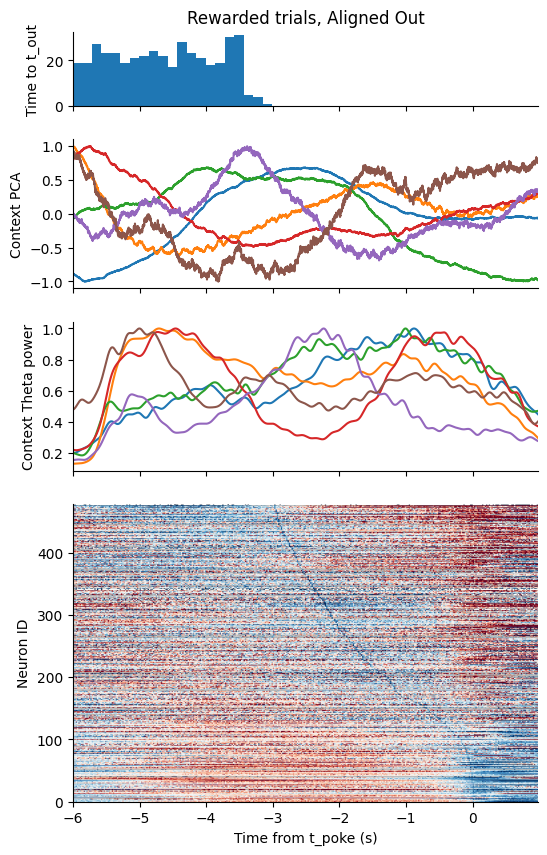

In [125]:
ind_sort = ind_reward_out
# ind_sort = ind_no_reward
# ind_sort = ind_run_sort


fig, ax = plt.subplots(
    nrows=4, height_ratios=[1, 2, 2, 4], sharex=True, figsize=(6, 10)
)
yy = results_reward_out.copy()[ind_sort]
yy = yy / np.mean(yy, axis=1, keepdims=True)
yy = np.log2(yy)

dur_bins = np.linspace(t_bins_reward_out[0], t_bins_reward_out[-1], 50)
ax[0].hist(reward_durations[~np.isnan(reward_durations)], bins=dur_bins)
ax[-1].imshow(
    yy,
    aspect="auto",
    extent=[t_bins_reward[0], t_bins_reward[-1], 0, len(yy)],
    cmap="RdBu",
    clim=(-1, 1),
)
# plt.colorbar()


# context
t_response = np.linspace(
    t_bins_reward[0], t_bins_reward[-1], reward_c_response.shape[0]
)
for i in range(6):
    color = plt.cm.Dark2(i)
    color = f"C{i}"
    val = reward_c_response[:, i]
    val = (val - np.mean(val)) / np.max(np.abs(val - np.mean(val)))
    ax[1].plot(t_response, val, color=color)

    val = reward_theta_response[:, i]
    # val = (val - np.mean(val)) / np.max(np.abs(val - np.mean(val)))
    val = val / np.max(val)
    ax[2].plot(t_response, val, color=color)

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
ax[-1].set_xlabel("Time from t_poke (s)")

ax[0].set_ylabel("Time to t_out")
ax[1].set_ylabel("Context PCA")
ax[2].set_ylabel("Context Theta power")
ax[3].set_ylabel("Neuron ID")

ax[0].set_title("Rewarded trials, Aligned Out")

## unrewarded poke in

In [ ]:
_df = trial_df[trial_df.reward == 0]
marks = _df.t_poke
marks = marks[~np.isnan(marks)]
marks = marks[:]

t_bins_no_reward = np.arange(0, 0.5, 0.02)
results = np.zeros((len(spikes), len(t_bins_no_reward) - 1))

for m in tqdm(marks):
    for i, s in enumerate(spikes):
        st = np.searchsorted(s, m + t_bins_no_reward[0])
        en = np.searchsorted(s, m + t_bins_no_reward[-1])
        if en <= st:
            continue
        delays = s[st:en] - m
        results[i, :] += np.histogram(delays, bins=t_bins_no_reward)[0]
results_no_reward = np.array(results)
ind_no_reward = np.argsort(np.argmax(results_no_reward, axis=1))

# durations
no_reward_durations = _df.t_out.values - _df.t_poke.values
no_reward_durations = no_reward_durations[~np.isnan(no_reward_durations)]

# Ccontext
no_reward_c_response = analysis.alligned_response(
    marks, t_plot=(t_bins_no_reward[0], t_bins_no_reward[-1]), pca=True
)
no_reward_c_response = no_reward_c_response.mean(axis=0)

# theta power
no_reward_theta_response = analysis.alligned_response(
    marks,
    t_plot=(t_bins_no_reward[0], t_bins_no_reward[-1]),
    passed_data=(power_df.values, power_df.index),
)
no_reward_theta_response = no_reward_theta_response.mean(axis=0)

100%|██████████| 991/991 [00:08<00:00, 121.10it/s]


/tmp/ipykernel_2134881/582244606.py:9: RuntimeWarning: invalid value encountered in divide
  yy = yy / np.mean(yy, axis=1, keepdims=True)
/tmp/ipykernel_2134881/582244606.py:10: RuntimeWarning: divide by zero encountered in log2
  yy = np.log2(yy)


Text(0.5, 1.0, 'Non-rewarded trials')

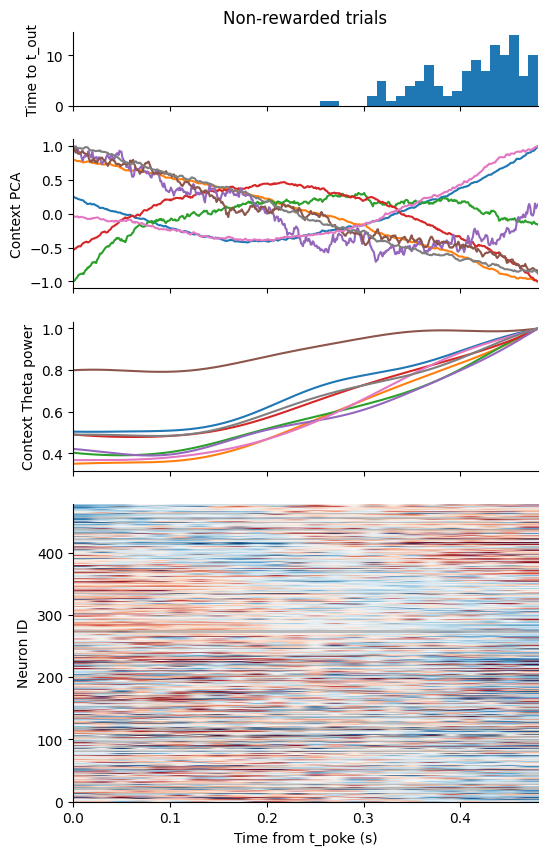

In [ ]:
ind_sort = ind_no_reward
ind_sort = ind_reward
# ind_sort = ind_run_sort
fig, ax = plt.subplots(
    nrows=4, height_ratios=[1, 2, 2, 4], sharex=True, figsize=(6, 10)
)

dur_bins = np.linspace(t_bins_no_reward[0], t_bins_no_reward[-1], 50)
ax[0].hist(no_reward_durations, bins=dur_bins)
yy = results_no_reward.copy()[ind_sort]
yy = yy / np.mean(yy, axis=1, keepdims=True)
yy = np.log2(yy)
ax[-1].imshow(
    yy,
    aspect="auto",
    extent=[t_bins_no_reward[0], t_bins_no_reward[-1], 0, len(yy)],
    cmap="RdBu",
    clim=(-1, 1),
)


# context
t_response = np.linspace(
    t_bins_no_reward[0], t_bins_no_reward[-1], no_reward_c_response.shape[0]
)
for i in range(8):
    # color = plt.cm.Dark2(i)
    color = f"C{i}"
    val = no_reward_c_response[:, i]
    val = (val - np.mean(val)) / np.max(np.abs(val - np.mean(val)))
    ax[1].plot(t_response, val, color=color)

    val = no_reward_theta_response[:, i]
    # val = (val - np.mean(val)) / np.max(np.abs(val - np.mean(val)))
    val = val / np.max(val)
    ax[2].plot(t_response, val, color=color)

for a in ax:
    a.spines[["top", "right"]].set_visible(False)
ax[-1].set_xlabel("Time from t_poke (s)")

ax[0].set_ylabel("Time to t_out")
ax[1].set_ylabel("Context PCA")
ax[2].set_ylabel("Context Theta power")
ax[3].set_ylabel("Neuron ID")
ax[0].set_title("Non-rewarded trials")

## all pokes

In [56]:
from spyglass.common.common_interval import Interval

marks = all_poke_intervals[:, 0]
marks = marks[~np.isnan(marks)]

reward_df = trial_df[trial_df.reward == 1]
reward_intervals = Interval(
    np.array([reward_df.t_poke.values, reward_df.t_out.values]).T
)

marks = reward_intervals.contains(marks)


marks = marks[:]

t_bins_poke = np.arange(-0.5, 0.5, 0.02)
results = np.zeros((len(spikes), len(t_bins_poke) - 1))

for m in tqdm(marks):
    for i, s in enumerate(spikes):
        st = np.searchsorted(s, m + t_bins_poke[0])
        en = np.searchsorted(s, m + t_bins_poke[-1])
        if en <= st:
            continue
        delays = s[st:en] - m
        results[i, :] += np.histogram(delays, bins=t_bins_poke)[0]

results_poke = np.array(results)
sort_on = np.abs(t_bins_poke[:-1]) < 0.08
ind_poke = np.argsort(np.argmax(results_poke[:, sort_on], axis=1))

100%|██████████| 7262/7262 [00:55<00:00, 130.64it/s]


In [57]:
sort_on = np.abs(t_bins_poke[:-1]) < 0.08
ind_poke = np.argsort(np.argmax(results_poke[:, sort_on], axis=1))

/tmp/ipykernel_2134881/4114545297.py:6: RuntimeWarning: divide by zero encountered in log2
  yy = np.log2(yy)


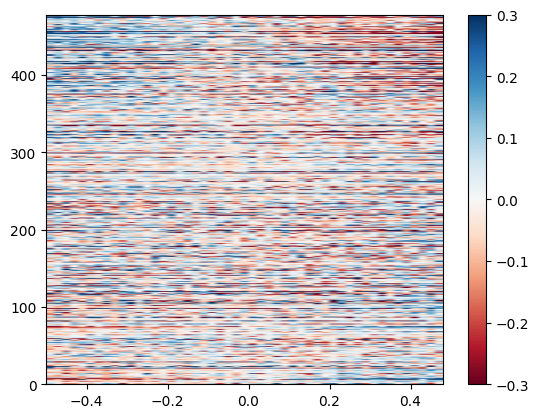

In [60]:
ind_sort = ind_poke
ind_sort = ind_reward

yy = results_poke.copy()[ind_sort]
yy = yy / np.mean(yy, axis=1, keepdims=True)
yy = np.log2(yy)
plt.imshow(
    yy,
    aspect="auto",
    extent=[t_bins_poke[0], t_bins_poke[-1], 0, len(yy)],
    cmap="RdBu",
    clim=(-0.3, 0.3),
)
plt.colorbar()
# plt.xlim(-0.2, 0.2)

## Raster

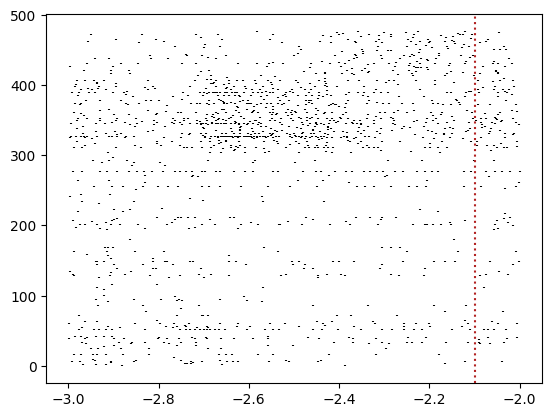

In [ ]:
t0 = trial_df[trial_df.reward == 1].t_poke.values[51]
t0 = trial_df[trial_df.reward == 1].t_out.values[151]
t_plot = [-3, -2]
# t_plot = [-4,2]
ind_sort = ind_run_restrictive
# ind_sort = ind_reward
ind_sort = None

min_spikes = 5
max_spikes = 100


fig, ax = plt.subplots()
s_plot = []
for s in spikes:
    ind = np.searchsorted(s, t0 + t_plot[0])
    ind_en = np.searchsorted(s, t0 + t_plot[1])
    s_plot.append(s[ind:ind_en] - t0)

if ind_sort is not None:
    s_plot = [s_plot[i] for i in ind_sort]
    s_plot = [s for s in s_plot if len(s) > min_spikes and len(s) < max_spikes]

if ind_sort is None:
    binned_rate_times = np.arange(t_plot[0], t_plot[1], 0.3)
    binned_rates = np.zeros((len(s_plot), len(binned_rate_times) - 1))
    for i, s in enumerate(s_plot):
        binned_rates[i, :] = np.histogram(s, bins=binned_rate_times)[0]
    ind_rate_sort = np.argsort(np.argmax(binned_rates, axis=1))
    s_plot = [s_plot[i] for i in ind_rate_sort]


plt.eventplot(s_plot, color="black")


pokes = all_poke_intervals[:, 0]
pokes = pokes[pokes > t0 + t_plot[0]]
pokes = pokes[pokes < t0 + t_plot[1]]
pokes = pokes - t0
pokes = pokes[~np.isnan(pokes)]
[ax.axvline(p, color="firebrick", ls=":") for p in pokes]

In [107]:
ax.axvlines?

Object `ax.axvlines` not found.


# context alligned to t_poke

In [85]:
t_plot = (0, 4)

marks = trial_df[trial_df.reward == 1].t_poke.values

response = analysis.alligned_response(marks, pca=True, t_plot=t_plot)

marks_neg = trial_df[trial_df.reward == 0].t_poke.values

response_neg = analysis.alligned_response(marks_neg, pca=True, t_plot=t_plot)

marks_run = trial_df.run_start.values
response_run = analysis.alligned_response(marks_run, pca=True, t_plot=t_plot)

(array([15., 69., 53., 58., 55., 55., 67., 45., 34., 18., 12., 12.,  8.,
         1.,  5.,  0.,  1.,  0.,  0.,  1.]),
 array([ 3.08799982,  3.45409983,  3.82019985,  4.18629986,  4.55239987,
         4.91849989,  5.2845999 ,  5.65069991,  6.01679993,  6.38289994,
         6.74899995,  7.11509997,  7.48119998,  7.84729999,  8.21340001,
         8.57950002,  8.94560003,  9.31170005,  9.67780006, 10.04390007,
        10.41000009]),
 <BarContainer object of 20 artists>)

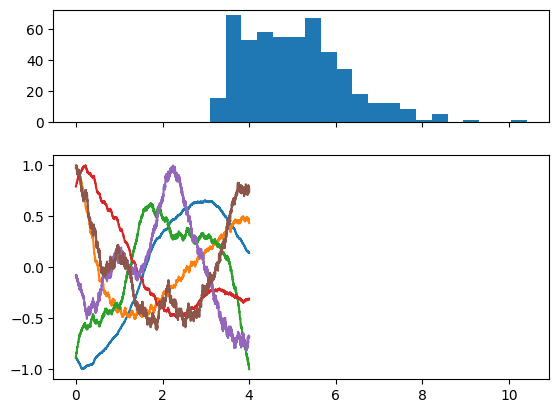

In [ ]:
fig, ax = plt.subplots(nrows=2, sharex=True, height_ratios=[1, 2])

yy = np.mean(response, axis=0)
yy = yy - np.mean(yy, axis=0)
yy = yy / np.max(np.abs(yy), axis=0)
tt = np.linspace(t_plot[0], t_plot[1], yy.shape[0])
ax[1].plot(tt, yy[:, :6])

_df = trial_df[trial_df.reward == 1]

durations = _df.t_out.values - _df.t_poke.values
ax[0].hist(durations, bins=20)

(array([ 56., 174., 154., 217., 194.,  76.,  40.,  13.,   9.,   9.,   6.,
          6.,   4.,   4.,   0.,   1.,   0.,   1.,   0.,   0.,   1.,   1.,
          1.,   2.,   2.,   2.,   2.,   1.,   1.,   0.,   1.,   1.,   0.,
          0.,   1.,   0.,   0.,   1.,   2.,   1.,   1.,   0.,   0.,   0.,
          0.,   1.,   0.,   0.,   0.,   1.]),
 array([0.25999999, 0.42705999, 0.59412   , 0.76118   , 0.92824   ,
        1.09530001, 1.26236001, 1.42942001, 1.59648002, 1.76354002,
        1.93060002, 2.09766003, 2.26472003, 2.43178003, 2.59884004,
        2.76590004, 2.93296004, 3.10002005, 3.26708005, 3.43414005,
        3.60120006, 3.76826006, 3.93532006, 4.10238007, 4.26944007,
        4.43650007, 4.60356008, 4.77062008, 4.93768008, 5.10474009,
        5.27180009, 5.43886009, 5.6059201 , 5.7729801 , 5.9400401 ,
        6.10710011, 6.27416011, 6.44122011, 6.60828012, 6.77534012,
        6.94240012, 7.10946012, 7.27652013, 7.44358013, 7.61064013,
        7.77770014, 7.94476014, 8.11182014, 8.

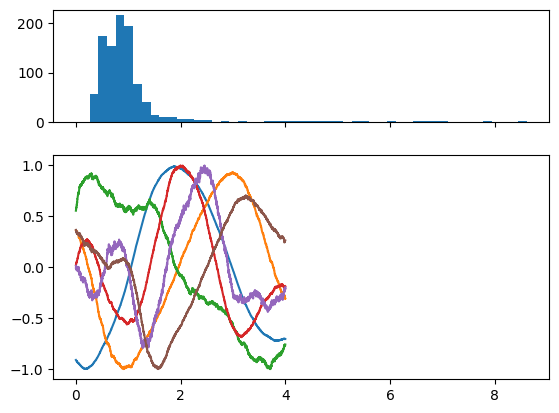

In [ ]:
fig, ax = plt.subplots(nrows=2, sharex=True, height_ratios=[1, 2])

yy = np.mean(response_neg, axis=0)
yy = yy - np.mean(yy, axis=0)
yy = yy / np.max(np.abs(yy), axis=0)

ax[1].plot(tt, yy[:, :6])

_df = trial_df[trial_df.reward == 0]
durations = _df.t_out.values - _df.t_poke.values
durations = durations[durations < 10]
ax[0].hist(durations, bins=50)

(array([ 19.,  81., 146., 161., 164., 108.,  58.,  37.,  19.,  17.,  14.,
         14.,  14.,  16.,  17.,  15.,  18.,  10.,  11.,   3.,   4.,   3.,
          4.,   2.,   1.,   2.,   5.,   2.,   3.,   1.,   1.,   2.,   2.,
          1.,   1.,   1.,   2.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,
          0.,   0.,   1.,   1.,   0.,   2.]),
 array([2.0769999 , 2.2200999 , 2.3631999 , 2.5062999 , 2.6493999 ,
        2.7924999 , 2.9355999 , 3.0786999 , 3.2217999 , 3.3648999 ,
        3.5079999 , 3.6510999 , 3.7941999 , 3.9372999 , 4.08039989,
        4.22349989, 4.36659989, 4.50969989, 4.65279989, 4.79589989,
        4.93899989, 5.08209989, 5.22519989, 5.36829989, 5.51139989,
        5.65449989, 5.79759989, 5.94069989, 6.08379989, 6.22689989,
        6.36999989, 6.51309988, 6.65619988, 6.79929988, 6.94239988,
        7.08549988, 7.22859988, 7.37169988, 7.51479988, 7.65789988,
        7.80099988, 7.94409988, 8.08719988, 8.23029988, 8.37339988,
        8.51649988, 8.65959988, 8.80269988, 8.

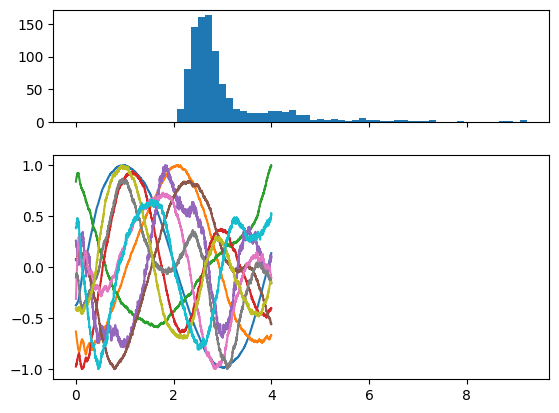

In [87]:
fig, ax = plt.subplots(nrows=2, sharex=True, height_ratios=[1, 2])

yy = np.mean(response_run, axis=0)
yy = yy - np.mean(yy, axis=0)
yy = yy / np.max(np.abs(yy), axis=0)

ax[1].plot(tt, yy[:, :10])

_df = trial_df[trial_df.reward == 0]
durations = -1 * (_df.run_start.values - _df.t_poke.values)
durations = durations[durations < 10]
ax[0].hist(durations, bins=50)

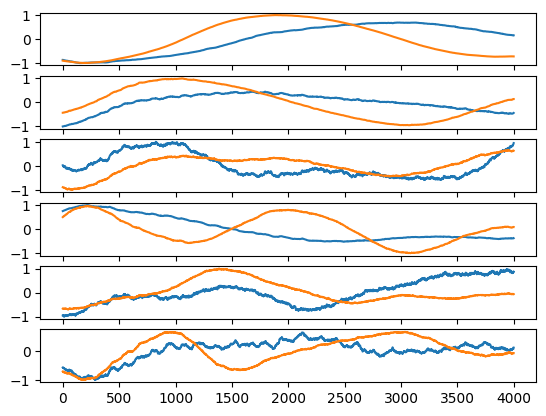

In [356]:
yy = np.mean(response, axis=0)
yy = yy - np.mean(yy, axis=0)
yy = yy / np.max(np.abs(yy), axis=0)

yy_neg = np.mean(response_neg, axis=0)
yy_neg = yy_neg - np.mean(yy_neg, axis=0)
yy_neg = yy_neg / np.max(np.abs(yy_neg), axis=0)


fig, ax = plt.subplots(nrows=6, sharex=True)
for i, a in enumerate(ax):
    a.plot(yy[:, i], label="reward")
    a.plot(yy_neg[:, i], label="no reward")
    # a.legend()

# pseudo-time context

In [ ]:
from spyglass.common.common_interval import Interval

t_port_norm = np.ones_like(analysis.t_interp) * -1
t_run_norm = np.ones_like(analysis.t_interp) * -1

for st, en in trial_df[["t_poke", "t_out"]].values:
    ind_st = np.searchsorted(analysis.t_interp, st)
    ind_en = np.searchsorted(analysis.t_interp, en)
    t_port_norm[ind_st:ind_en] = np.linspace(0, 1, ind_en - ind_st)

for st, en in trial_df[["run_start", "t_poke"]].values:
    if np.isnan(st) or np.isnan(en):
        continue
    ind_st = np.searchsorted(analysis.t_interp, st)
    ind_en = np.searchsorted(analysis.t_interp, en)
    t_run_norm[ind_st:ind_en] = np.linspace(0, 1, ind_en - ind_st)

reward_intervals = np.array(
    [trial_df[trial_df.reward == 1][["t_poke", "t_out"]].values]
)[0]
no_reward_intervals = np.array(
    [trial_df[trial_df.reward == 0][["t_poke", "t_out"]].values]
)[0]
run_intervals = np.array([trial_df[["run_start", "t_poke"]].values])[0]

q_intervals = []
q_bins = np.percentile(
    trial_df.Q_stem_trial[trial_df.n_pre_switch > 0], np.linspace(5, 95, 6)
)
for i in range(q_bins.size - 1):
    _df = trial_df[trial_df.n_pre_switch > 0]
    ind = np.logical_and(
        _df.Q_stem_trial >= q_bins[i], _df.Q_stem_trial <= q_bins[i + 1]
    )
    q_intervals.append(Interval(_df[["run_start", "t_out"]].values[ind]))

run_intervals = run_intervals[~np.isnan(run_intervals).any(axis=1)]
reward_intervals = reward_intervals[~np.isnan(reward_intervals).any(axis=1)]
no_reward_intervals = no_reward_intervals[~np.isnan(no_reward_intervals).any(axis=1)]


pre_switch_intervals = []
for n in range(5):
    _df = trial_df[trial_df.n_pre_switch == n]
    _df = _df[~np.isnan(_df.run_start) & ~np.isnan(_df.t_out)]
    pre_switch_intervals.append(Interval(_df[["run_start", "t_out"]].values))

In [159]:
t_bins = np.linspace(0, 1, 1000)


reward_context, bins = analysis.bin_context_by_feature(
    t_port_norm,
    analysis.t_interp,
    pca=True,
    interpolated=True,
    valid_intervals=reward_intervals,
    bins=t_bins,
)

no_reward_context, bins = analysis.bin_context_by_feature(
    t_port_norm,
    analysis.t_interp,
    pca=True,
    interpolated=True,
    valid_intervals=no_reward_intervals,
    bins=t_bins,
)

run_context, bins = analysis.bin_context_by_feature(
    t_run_norm,
    analysis.t_interp,
    pca=True,
    interpolated=True,
    valid_intervals=run_intervals,
    bins=t_bins,
)

from tqdm import tqdm

q_run_context = []
for q_int in tqdm(q_intervals):
    _interval = q_int.intersect(run_intervals)
    context, bins = analysis.bin_context_by_feature(
        t_run_norm,
        analysis.t_interp,
        pca=True,
        interpolated=True,
        valid_intervals=_interval,
        bins=t_bins,
    )
    q_run_context.append(context)

q_reward_context = []
for q_int in tqdm(q_intervals):
    _interval = q_int.intersect(reward_intervals)
    context, bins = analysis.bin_context_by_feature(
        t_port_norm,
        analysis.t_interp,
        pca=True,
        interpolated=True,
        valid_intervals=_interval,
        bins=t_bins,
    )
    q_reward_context.append(context)

q_no_reward_context = []
for q_int in tqdm(q_intervals):
    _interval = q_int.intersect(no_reward_intervals)
    context, bins = analysis.bin_context_by_feature(
        t_port_norm,
        analysis.t_interp,
        pca=True,
        interpolated=True,
        valid_intervals=_interval,
        bins=t_bins,
    )
    q_no_reward_context.append(context)

100%|██████████| 5/5 [00:27<00:00,  5.43s/it]


In [ ]:
pre_switch_run_context = []
for pre_int in tqdm(pre_switch_intervals):
    _interval = pre_int.intersect(run_intervals)
    context, bins = analysis.bin_context_by_feature(
        t_run_norm,
        analysis.t_interp,
        pca=True,
        interpolated=True,
        valid_intervals=_interval,
        bins=t_bins,
    )
    pre_switch_run_context.append(context)

pre_switch_reward_context = []
for pre_int in tqdm(pre_switch_intervals):
    _interval = pre_int.intersect(reward_intervals)
    context, bins = analysis.bin_context_by_feature(
        t_port_norm,
        analysis.t_interp,
        pca=True,
        interpolated=True,
        valid_intervals=_interval,
        bins=t_bins,
    )
    pre_switch_reward_context.append(context)

pre_switch_no_reward_context = []
for pre_int in tqdm(pre_switch_intervals):
    _interval = pre_int.intersect(no_reward_intervals)
    context, bins = analysis.bin_context_by_feature(
        t_port_norm,
        analysis.t_interp,
        pca=True,
        interpolated=True,
        valid_intervals=_interval,
        bins=t_bins,
    )
    pre_switch_no_reward_context.append(context)

100%|██████████| 5/5 [00:26<00:00,  5.36s/it]


In [169]:
from spyglass.utils.dj_helper_fn import bytes_to_human_readable

bytes_to_human_readable(97057085856)

'90.39 GB'

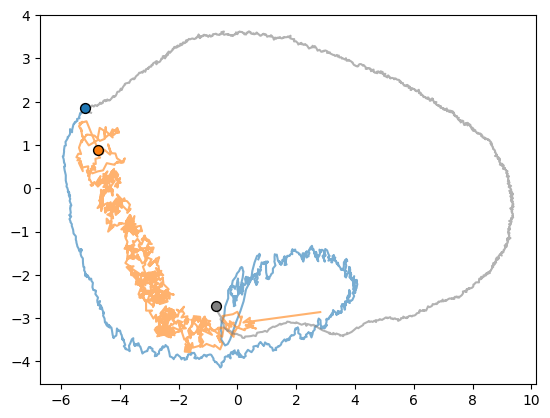

In [ ]:
pc_ = [
    0,
    1,
]

c_list = [
    reward_context,
    no_reward_context,
    run_context,
]
color_list = ["tab:blue", "tab:orange", "grey"]

for context, color in zip(c_list, color_list):
    context_mean = np.array([np.mean(c, axis=0) for c in context])
    # context_mean = smooth(context_mean, 33, axis=0)

    plt.plot(context_mean[:, pc_[0]], context_mean[:, pc_[1]], color=color, alpha=0.6)
    plt.scatter(
        context_mean[0, pc_[0]],
        context_mean[0, pc_[1]],
        color=color,
        s=50,
        edgecolors="black",
        zorder=10,
    )

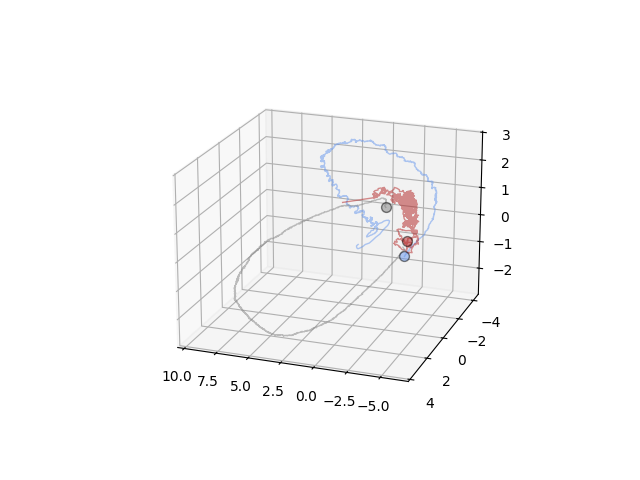

In [189]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

pc_ = [
    0,
    1,
    2,
]


# pc_ = [9, 4, 8]
def plot_ref(ax, alpha=0.5):
    c_list = [
        reward_context,
        no_reward_context,
        run_context,
    ]
    color_list = ["cornflowerblue", "firebrick", "grey"]

    for context, color in zip(c_list, color_list):
        context_mean = np.array([np.mean(c, axis=0) for c in context])
        ax.plot(
            context_mean[:, pc_[0]],
            context_mean[:, pc_[1]],
            context_mean[:, pc_[2]],
            color=color,
            lw=1,
            alpha=alpha,
        )
        ax.scatter(
            context_mean[0, pc_[0]],
            context_mean[0, pc_[1]],
            context_mean[0, pc_[2]],
            color=color,
            s=50,
            edgecolor="k",
            alpha=alpha,
        )

    ax.view_init(elev=20, azim=110)


plot_ref(ax)

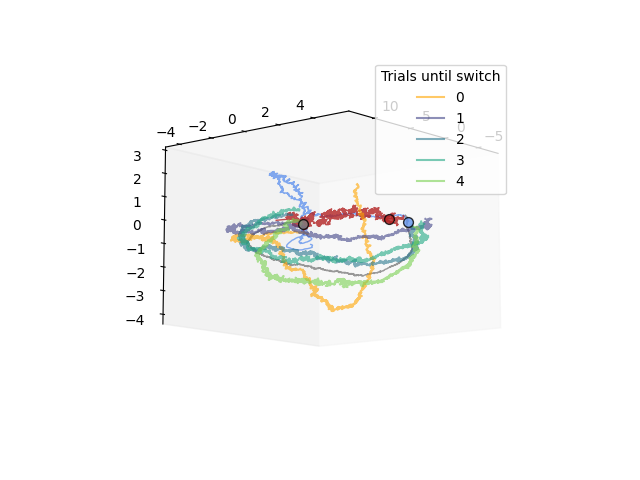

In [197]:
%matplotlib ipympl


fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
plot_ref(ax, alpha=0.8)

# for i, context in enumerate(q_run_context):
#     context_mean = np.array([np.mean(c, axis=0) for c in context])
#     color = plt.cm.viridis(i / len(q_run_context))

#     ax.plot(
#         context_mean[:, pc_[0]],
#         context_mean[:, pc_[1]],
#         context_mean[:, pc_[2]],
#         color=color,
#         label = f"Q bin {i+1}",
#         # s=50,
#         # edgecolor="k",
#     )

for i, context in enumerate(pre_switch_run_context):
    context_mean = np.array([np.mean(c, axis=0) for c in context])
    color = plt.cm.viridis(i / len(pre_switch_reward_context))
    if i == 0:
        color = "orange"
    ax.plot(
        context_mean[:, pc_[0]],
        context_mean[:, pc_[1]],
        context_mean[:, pc_[2]],
        color=color,
        label = i,
        alpha = .6,
        # s=50,
        # edgecolor="k",
    )

ax.legend(title="Trials until switch")
ax.grid(False)
ax.view_init(elev=-10, azim=40)

80
150
48
62
24


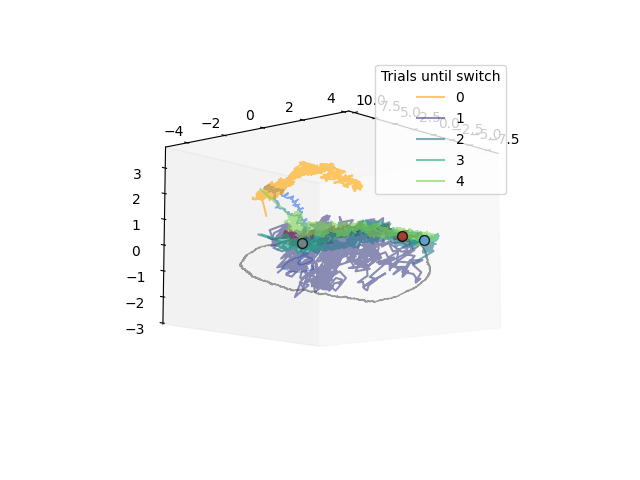

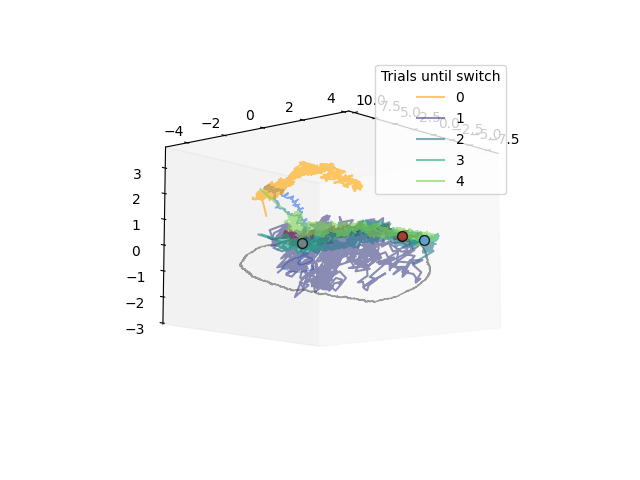

In [ ]:
# %matplotlib ipympl


fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
plot_ref(ax, alpha=0.8)

# for i, context in enumerate(q_run_context):
#     context_mean = np.array([np.mean(c, axis=0) for c in context])
#     color = plt.cm.viridis(i / len(q_run_context))

#     ax.plot(
#         context_mean[:, pc_[0]],
#         context_mean[:, pc_[1]],
#         context_mean[:, pc_[2]],
#         color=color,
#         label = f"Q bin {i+1}",
#         # s=50,
#         # edgecolor="k",
#     )

for i, context in enumerate(pre_switch_no_reward_context):
    n = len(context[0])
    print(n)
    if n < 10:
        continue
    context_mean = np.array([np.mean(c, axis=0) for c in context])
    color = plt.cm.viridis(i / len(pre_switch_reward_context))
    if i == 0:
        color = "orange"
    # if i ==1:
    #     continue
    ax.plot(
        context_mean[:, pc_[0]],
        context_mean[:, pc_[1]],
        context_mean[:, pc_[2]],
        color=color,
        label=i,
        alpha=0.6,
        # s=50,
        # edgecolor="k",
    )

ax.legend(title="Trials until switch")
ax.grid(False)
ax.view_init(elev=-10, azim=40)
fig.show()

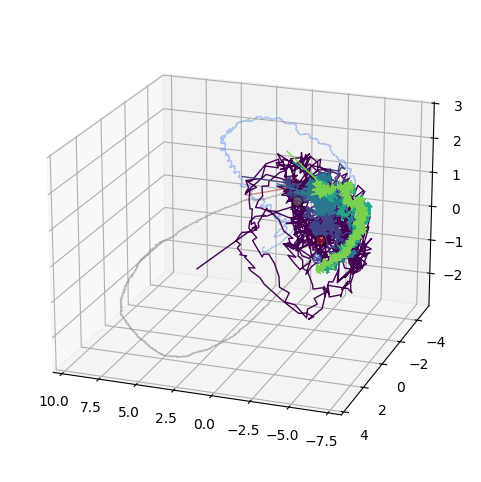

In [172]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
plot_ref(ax, alpha=0.5)

for i, context in enumerate(q_no_reward_context):
    context_mean = np.array([np.mean(c, axis=0) for c in context])
    color = plt.cm.viridis(i / len(q_reward_context))

    ax.plot(
        context_mean[:, pc_[0]],
        context_mean[:, pc_[1]],
        context_mean[:, pc_[2]],
        color=color,
        lw=1,
    )

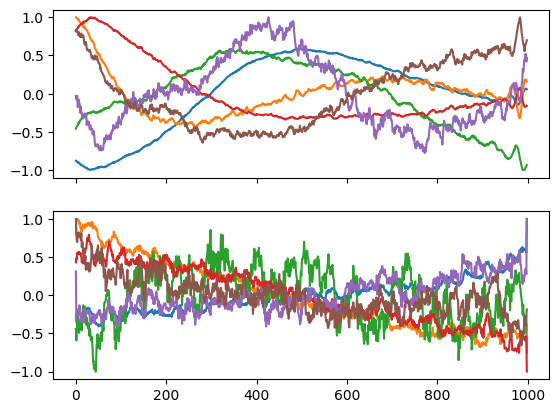

In [ ]:
fig, ax = plt.subplots(nrows=2, sharex=True)

context = reward_context
context_mean = np.array([np.mean(c, axis=0) for c in context])
context_mean = context_mean - np.mean(context_mean, axis=0)
context_mean = context_mean / np.max(np.abs(context_mean), axis=0)
ax[0].plot(context_mean[:, :6])

context = no_reward_context
context_mean = np.array([np.mean(c, axis=0) for c in context])
context_mean = context_mean - np.mean(context_mean, axis=0)
context_mean = context_mean / np.max(np.abs(context_mean), axis=0)
ax[1].plot(context_mean[:, :6])

# Poke precessions?

In [24]:
all_pokes = all_poke_intervals[:, 0]
_df = trial_df[trial_df.reward == 1]


t_from_first_poke = []
pokes = []
for st, en in _df[["t_poke", "t_out"]].values:
    pokes_in_interval = all_pokes[(all_pokes > st) & (all_pokes < en)]
    if len(pokes_in_interval) == 0:
        continue
    t_from_first_poke.extend(pokes_in_interval - pokes_in_interval[0])
    pokes.extend(pokes_in_interval)
# fig = plt.figure()
# plt.hist(t_from_first_poke, bins=50)

poke_phase_ind = np.searchsorted(phase_df.index.values, pokes)

c_response = analysis.alligned_response(_df.t_poke.values, t_plot=(-1, 6), pca=True)
power_response = analysis.alligned_response(
    _df.t_poke.values, t_plot=(-1, 6), passed_data=(power_df.values, power_df.index)
)
c_response = c_response.mean(axis=0)
power_response = power_response.mean(axis=0)

/tmp/ipykernel_2530941/415493414.py:40: RuntimeWarning: invalid value encountered in divide
  h = h / h.sum(axis=1, keepdims=True)


3.181359649204854


/tmp/ipykernel_2530941/415493414.py:40: RuntimeWarning: invalid value encountered in divide
  h = h / h.sum(axis=1, keepdims=True)


3.181359649204854


/tmp/ipykernel_2530941/415493414.py:40: RuntimeWarning: invalid value encountered in divide
  h = h / h.sum(axis=1, keepdims=True)
/tmp/ipykernel_2530941/415493414.py:40: RuntimeWarning: invalid value encountered in divide
  h = h / h.sum(axis=1, keepdims=True)


...

3.181359649204854
3.181359649204854


/tmp/ipykernel_2530941/415493414.py:40: RuntimeWarning: invalid value encountered in divide
  h = h / h.sum(axis=1, keepdims=True)
/tmp/ipykernel_2530941/415493414.py:40: RuntimeWarning: invalid value encountered in divide
  h = h / h.sum(axis=1, keepdims=True)


3.181359649204854
3.181359649204854


/tmp/ipykernel_2530941/415493414.py:40: RuntimeWarning: invalid value encountered in divide
  h = h / h.sum(axis=1, keepdims=True)


3.181359649204854


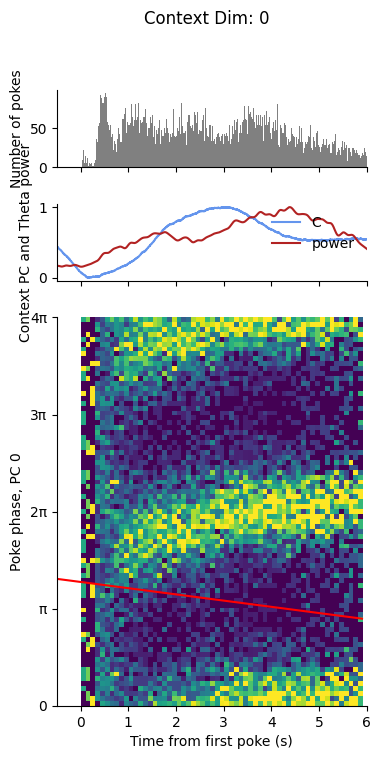

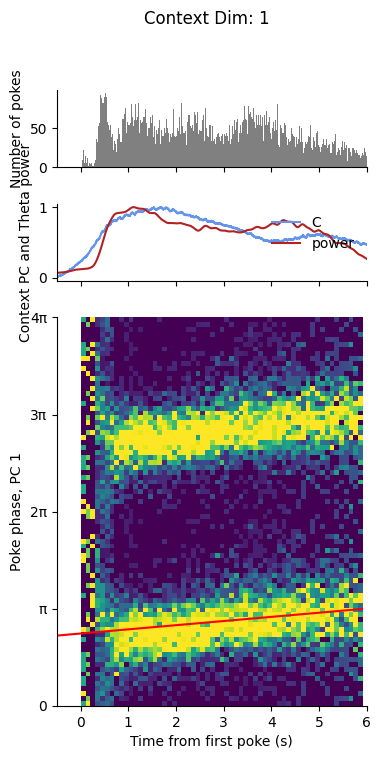

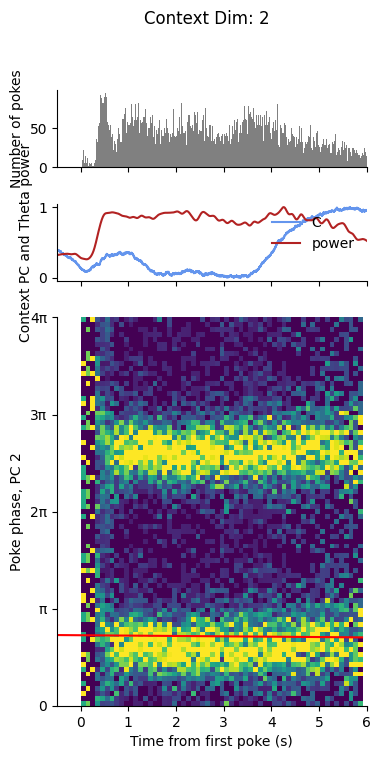

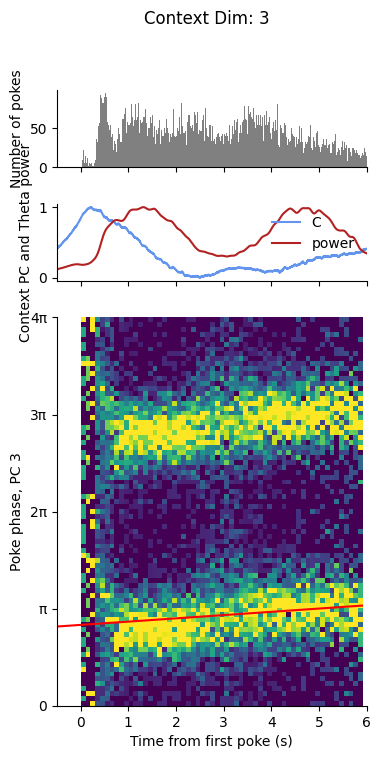

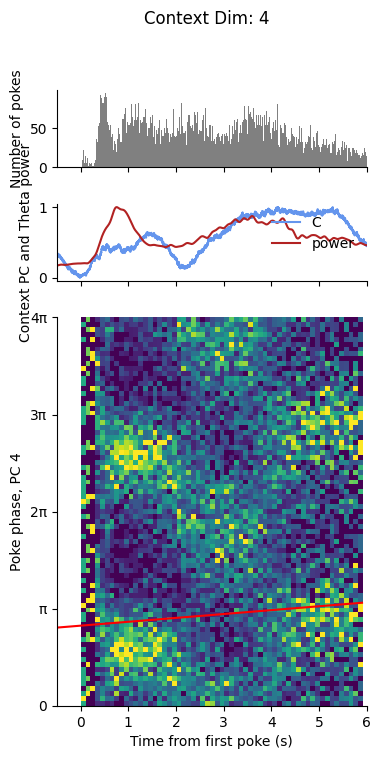

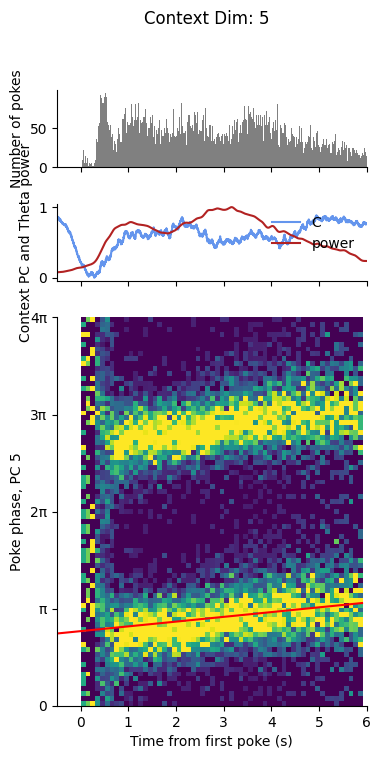

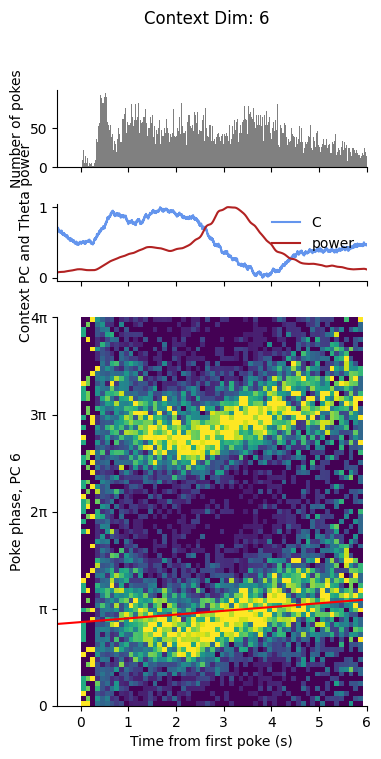

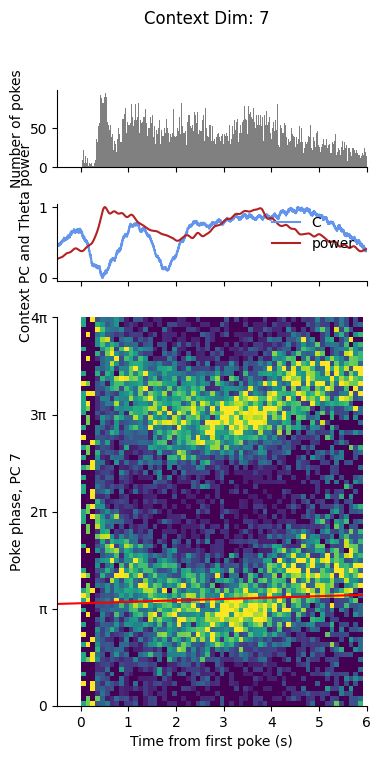

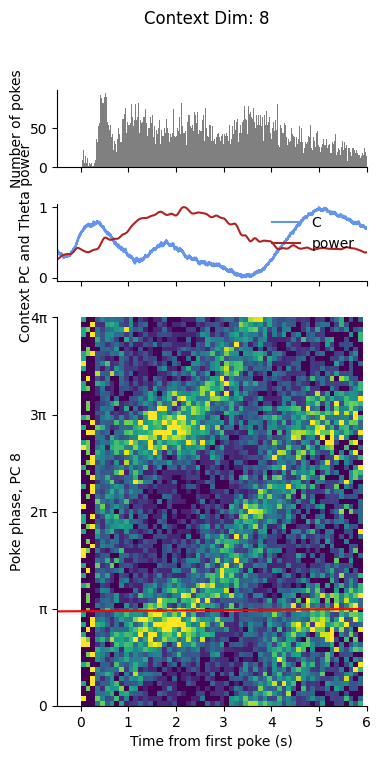

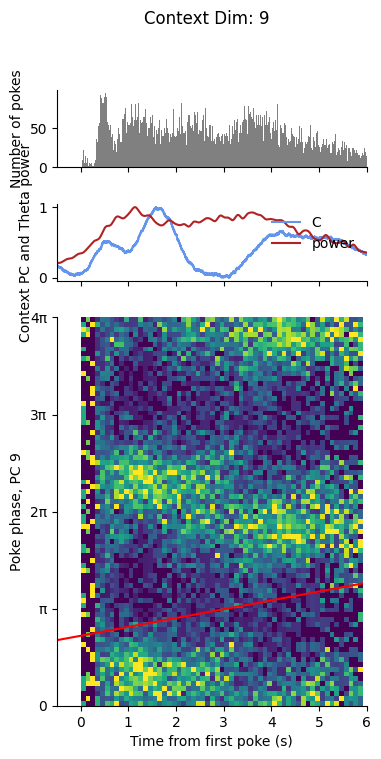

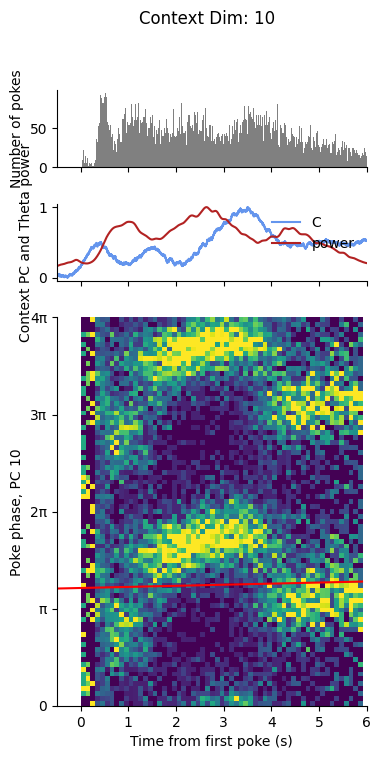

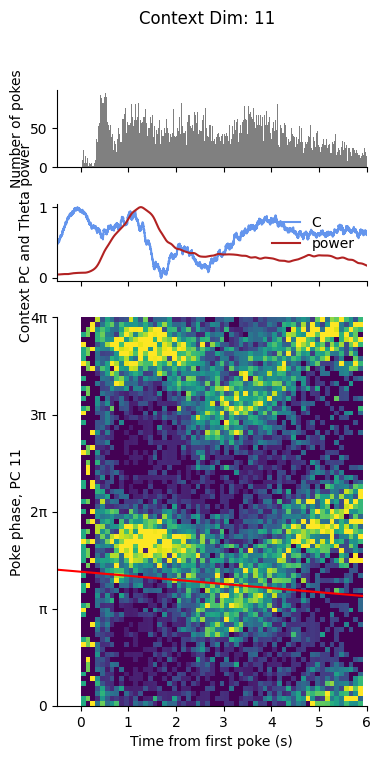

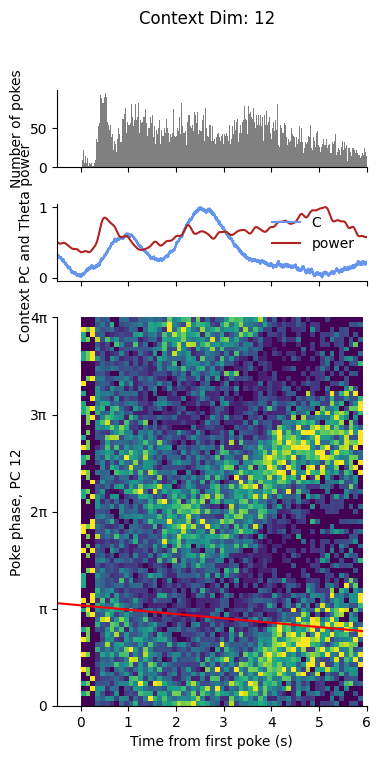

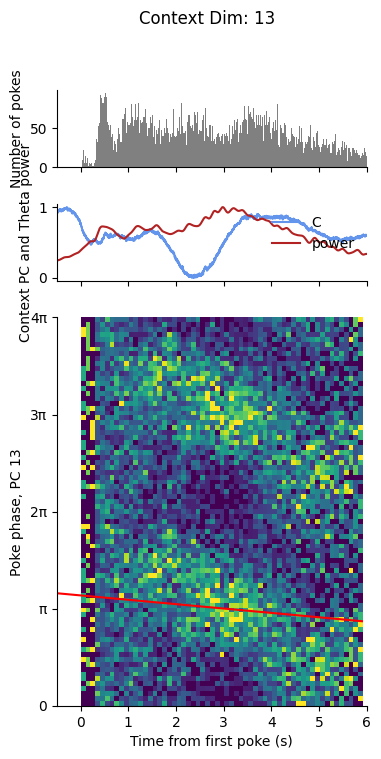

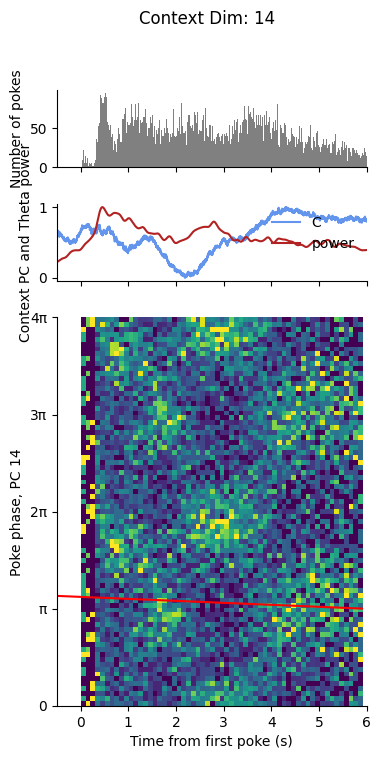

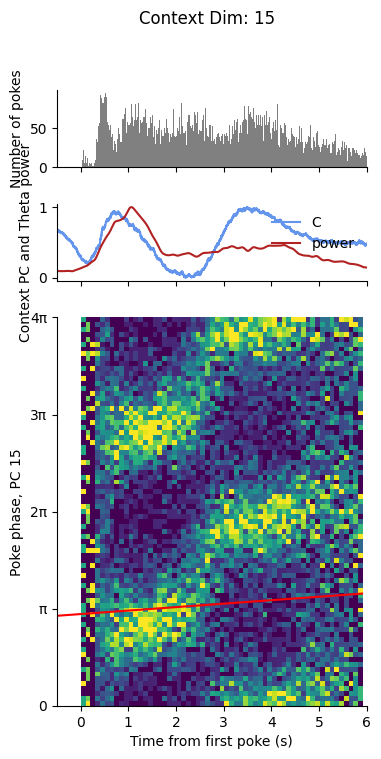

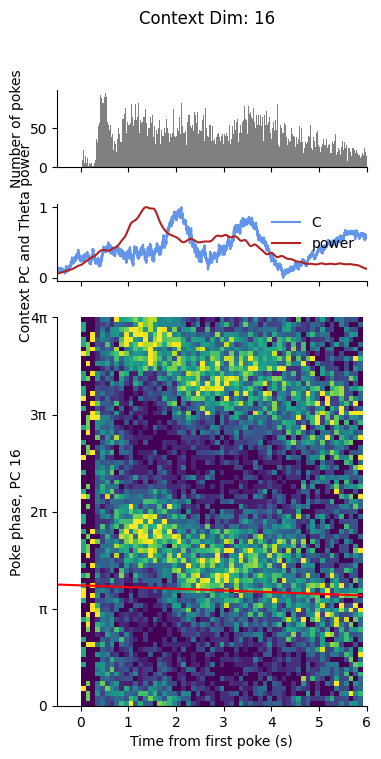

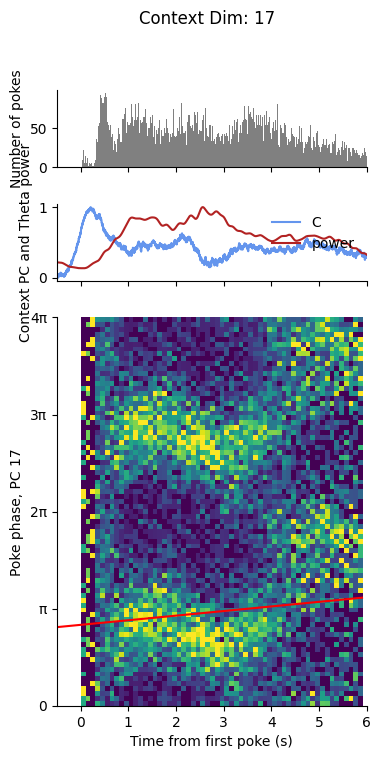

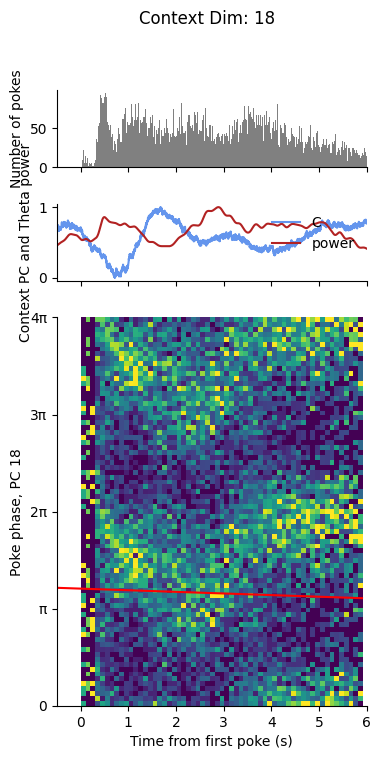

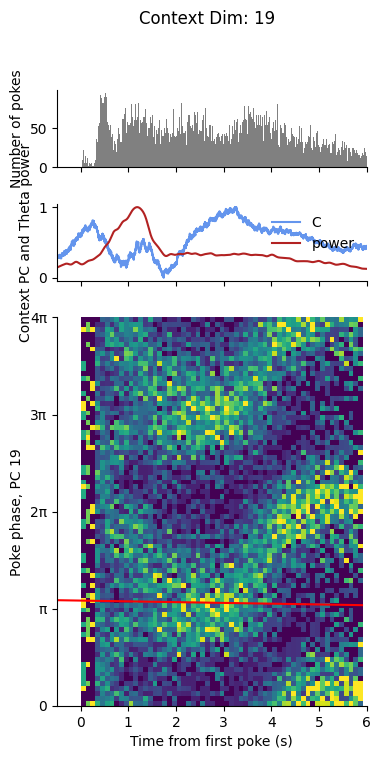

In [25]:
for pc in range(analysis.context_dim):
    poke_phase = phase_df[pc].iloc[poke_phase_ind]

    t_rng = (-0.5, 6)
    t_step = 0.1
    phase_bins = 80

    # t_rng = (.2,.8)
    # t_step = .05
    # phase_bins = 10

    plot_t = np.concatenate([t_from_first_poke, t_from_first_poke])
    plot_phase = np.concatenate([poke_phase, poke_phase + 2 * np.pi])
    ind = np.logical_and(plot_t > max(t_rng[0], 0), plot_t < t_rng[1])
    plot_t = plot_t[ind]
    plot_phase = plot_phase[ind]

    fig, ax = plt.subplots(
        nrows=3, sharex=True, height_ratios=[1, 1, 5], figsize=(4, 8)
    )
    ax[0].hist(
        plot_t[plot_t > 0],
        bins=300,
        facecolor="grey",
    )

    t_response = np.linspace(-1, 6, c_response.shape[0])
    val = c_response[:, pc]
    val = (val - np.min(val)) / np.max(np.abs(val - np.min(val)))
    ax[1].plot(t_response, val, color="cornflowerblue", label="C")
    val = power_response[:, pc]
    val = val / np.max(val)
    ax[1].plot(t_response, val, color="firebrick", label="power")
    ax[1].legend(frameon=False, loc="upper right")
    # ax[1].scatter(plot_t, plot_phase, alpha=0.1)

    bx = np.arange(*t_rng, t_step)
    by = np.linspace(0, 4 * np.pi, phase_bins)
    h, _, _ = np.histogram2d(plot_t, plot_phase, bins=[bx, by])
    h = h / h.sum(axis=1, keepdims=True)
    extent = [bx[0], bx[-1], by[0], by[-1]]
    ax[-1].imshow(
        h.T, aspect="auto", extent=extent, origin="lower", clim=(0, 3 / phase_bins)
    )
    h.shape

    ind_center = np.logical_and(by[:-1] > np.pi, by[:-1] < 3 * np.pi)
    # ind_center = np.arange(len(by)-1)
    phase_center = by[:-1][ind_center][np.argmax(np.sum(h[:, ind_center], axis=0))]
    print(phase_center)
    ind_fit = np.logical_and(
        plot_phase > phase_center - np.pi, plot_phase < phase_center + np.pi
    )
    fit_phase = plot_phase[ind_fit]
    fit_t = plot_t[ind_fit]

    from scipy.stats import linregress

    fit_result = linregress(fit_t, fit_phase)
    fit_line = fit_result.intercept + fit_result.slope * bx

    plt.plot(bx, fit_line, color="red")

    ax[-1].set_yticks(
        [0, np.pi, 2 * np.pi, 3 * np.pi, 4 * np.pi], labels=["0", "π", "2π", "3π", "4π"]
    )
    ax[-1].set_xlabel("Time from first poke (s)")
    ax[-1].set_ylabel(f"Poke phase, PC {pc}")
    ax[1].set_ylabel("Context PC and Theta power")
    ax[0].set_ylabel("Number of pokes")
    for a in ax:
        a.spines[["top", "right"]].set_visible(False)
    ax[-1].set_xlim(t_rng)
    fig.suptitle(f"Context Dim: {pc}")

# Precession of relative phase

In [10]:
%load_ext autoreload
%autoreload 2

In [ ]:
t_from_first_poke = np.ones_like(analysis.t_interp) * -1
for st, en in rewarded_port_intervals:
    ind_st = np.searchsorted(analysis.t_interp, st)
    ind_en = np.searchsorted(analysis.t_interp, en)
    t_from_first_poke[ind_st:ind_en] = analysis.t_interp[ind_st:ind_en] - st


response = analysis.alligned_response(
    rewarded_port_intervals[:, 0], t_plot=(-1, 6), pca=True
)
response = response.mean(axis=0)
response = response - np.mean(response, axis=0)
response = response / np.max(np.abs(response), axis=0)
t_response = np.linspace(-1, 6, response.shape[0])


pc_ref = 1
pc_display = 4

H, bt, b_phase = analysis.bin_context_by_feature_2d(
    t_from_first_poke,
    analysis.t_interp,
    phase_df[pc_ref].values,
    phase_df.index.values,
    passed_data=(phase_df.index.values, phase_df[pc_display].values),
    valid_intervals=rewarded_port_intervals,
    bins_1=np.arange(0, 6, 0.01),
    bins_2=np.linspace(0, 2 * np.pi, 50),
)

In [36]:
response.shape

(7000, 20)

(-1.0, 6.0)

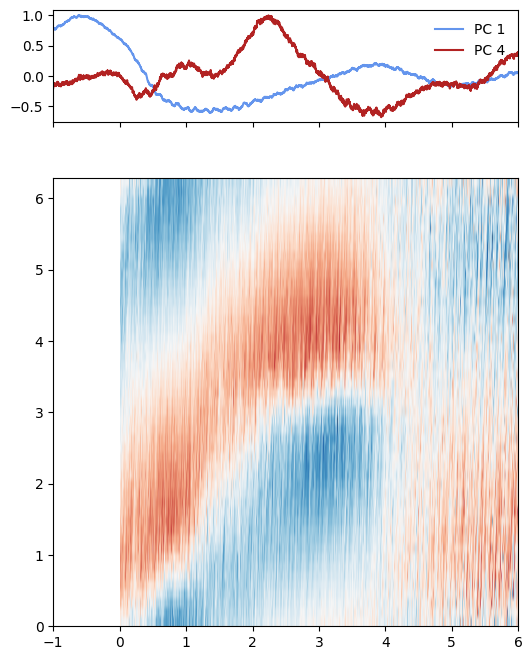

In [ ]:
fig, ax = plt.subplots(nrows=2, sharex=True, height_ratios=[1, 4], figsize=(6, 8))
ax[0].plot(
    t_response, response[:, pc_ref], color="cornflowerblue", label=f"PC {pc_ref}"
)
ax[0].plot(
    t_response, response[:, pc_display], color="firebrick", label=f"PC {pc_display}"
)
ax[0].legend(frameon=False, loc="upper right")
mean_vals = np.zeros((bt.size - 1, b_phase.size - 1))

for i in range(bt.size - 1):
    for j in range(b_phase.size - 1):
        vals = H[i][j]
        mean_vals[i, j] = np.mean(vals)

# mean_vals = mean_vals / np.mean(mean_vals, axis=1, keepdims=True)
cmap = "viridis"
cmap = "RdBu"

plt.imshow(
    mean_vals.T,
    aspect="auto",
    origin="lower",
    extent=[bt[0], bt[-1], b_phase[0], b_phase[-1]],
    cmap=cmap,
)

plt.xlim(-1, 6)
# plt.colorbar()
# plt.xlim(1,2)

In [41]:
t_response

array([-1.        , -0.99899986, -0.99799971, ...,  5.99799971,
        5.99899986,  6.        ])